# Homework 1 scRNA seq basic processing

# Load packages

In [1]:
library(dplyr)
library(cowplot)
library(Seurat)
library(ggplot2)
library(psych)
library(qgraph)
library(igraph)
library(Matrix)
library(SeuratWrappers)
library(pryr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Attaching SeuratObject

Attaching sp

Warning message:
“package ‘ggplot2’ was built under R version 4.1.3”

Attaching package: ‘psych’


The following objects are masked from ‘package:ggplot2’:

    %+%, alpha



Attaching package: ‘igraph’


The following objects are masked from ‘package:dplyr’:

    as_data_frame, groups, union


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union



Attaching package: ‘pryr’


The following object is masked from ‘package:igraph’:

    compose




# Load data

In [2]:
sample1dir <- "./data/Sample1"
sample2dir <- "./data/Sample2"

data1 <- Read10X(sample1dir,gene.column = 1)
data2 <- Read10X(sample2dir,gene.column = 1)

su1 <- CreateSeuratObject(data1) # Seurat object for data 1
su2 <- CreateSeuratObject(data2) # Seurat object for data 2

## Look at data distribution

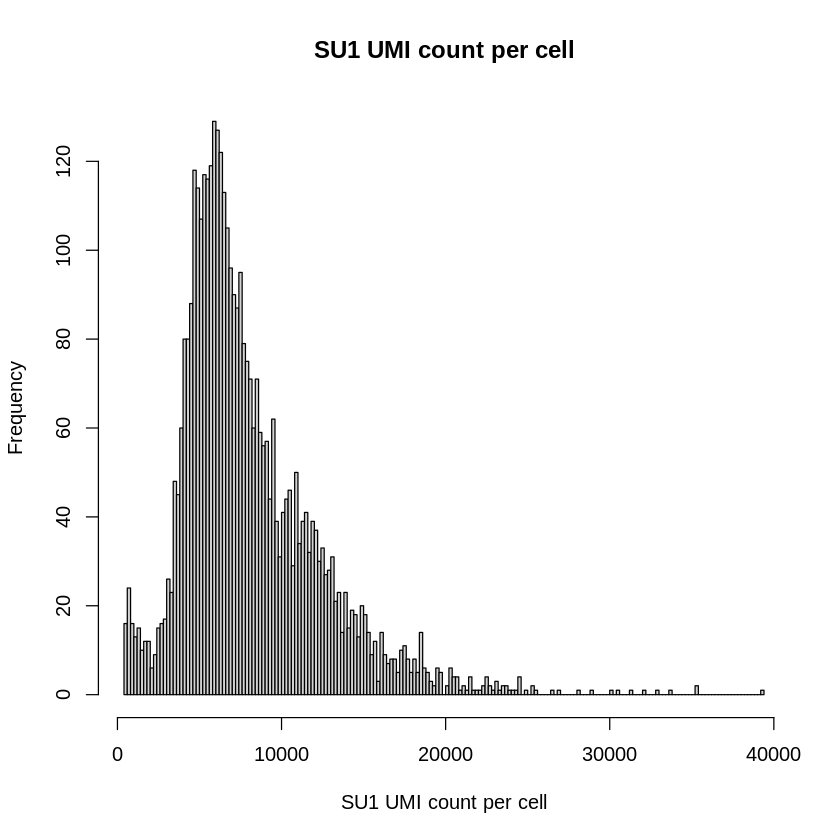

In [3]:
hist(colSums(su1),
     breaks = 150, main = "SU1 UMI count per cell",
     xlab = "SU1 UMI count per cell")

> Cells with low counts and high counts both present in small numbers

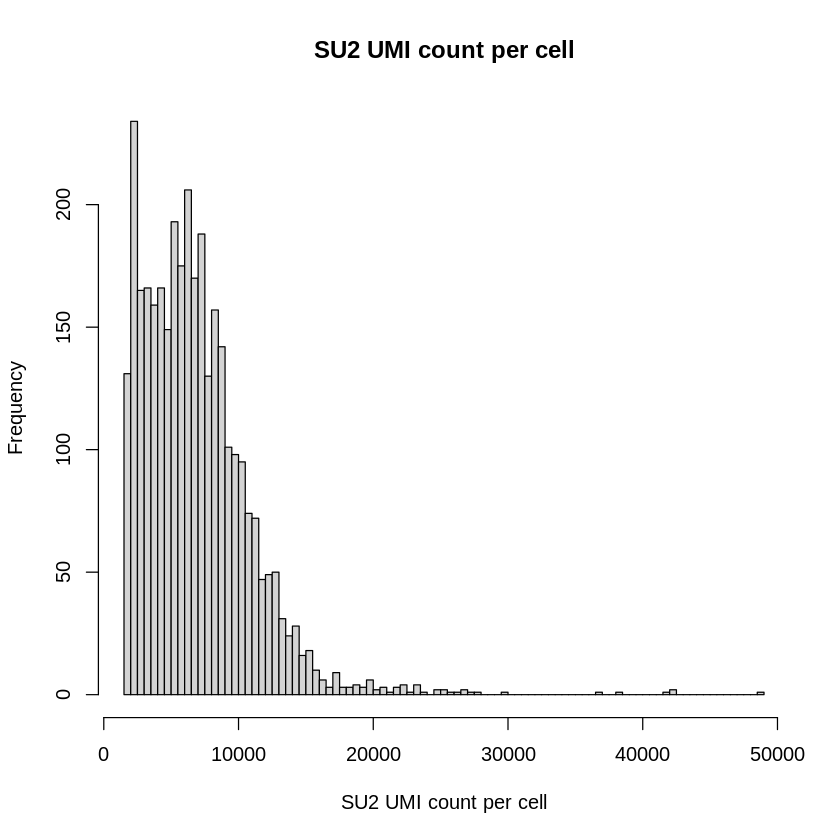

In [4]:
hist(colSums(su2),
     breaks = 150, main = "SU2 UMI count per cell",
     xlab = "SU2 UMI count per cell")

> Lots of cells have low UMI count, also some cells with high UMI count

In [5]:
dim(su1)
dim(su2)
# Feature * Cell

[1] 36601  4000

[1] 24670  3317

In [6]:
rm(data1)
rm(data2)
gc() # Release data1 and data2 from memory

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,3364271,179.7,5643987,301.5,5643987,301.5
Vcells,27434760,209.4,63731332,486.3,61790585,471.5


# QC Filtering

## Compute mito %

In [3]:
su1[["percent.mt"]] <- PercentageFeatureSet(su1, pattern = "^MT-")
su2[["percent.mt"]] <- PercentageFeatureSet(su2, pattern = "^MT-")

## Plot for su1

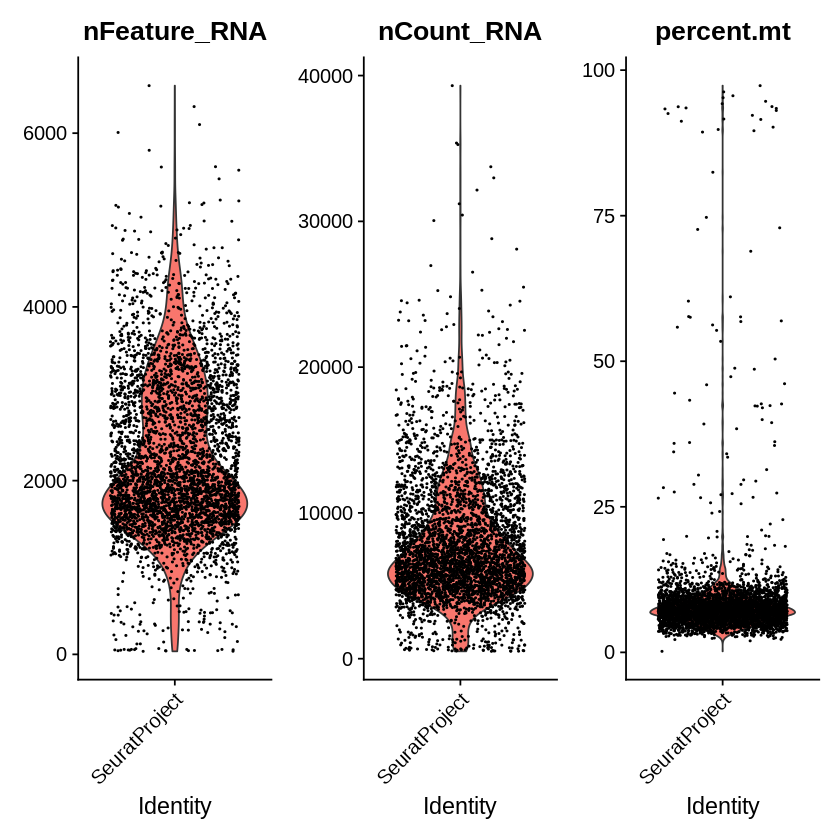

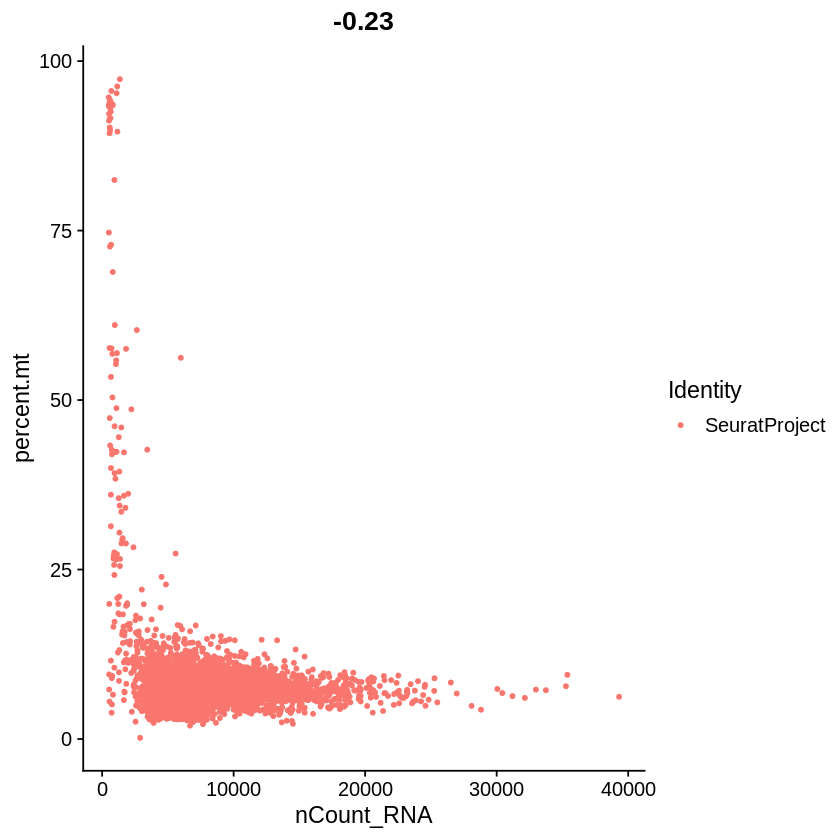

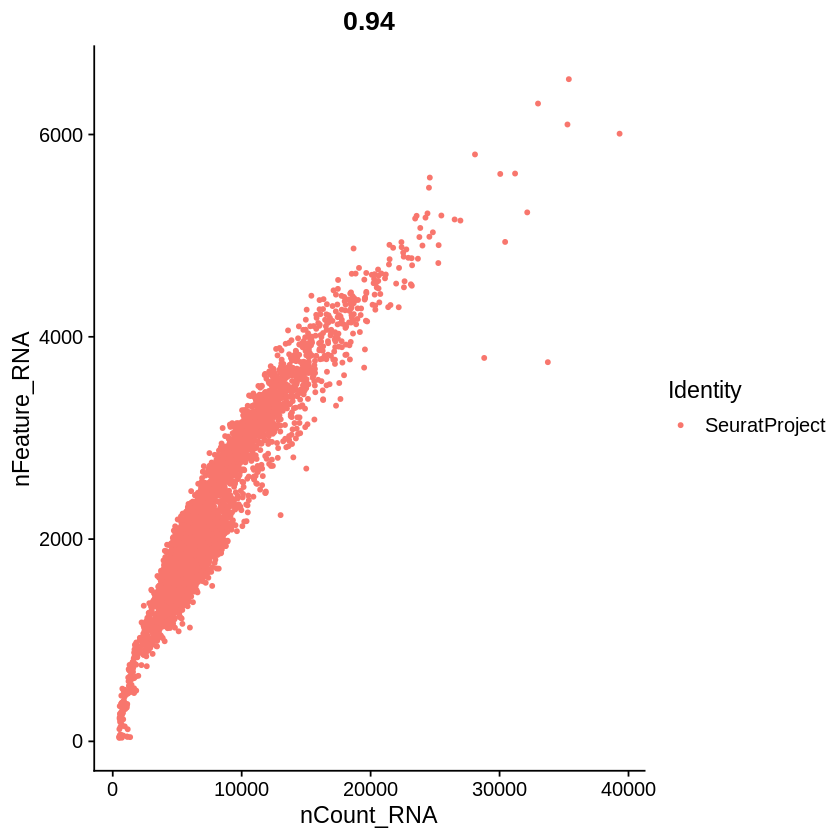

In [4]:
VlnPlot(su1, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol = 3, pt.size = 0.2)
FeatureScatter(su1, feature1 = "nCount_RNA", feature2 = "percent.mt")
FeatureScatter(su1, feature1 = "nCount_RNA", feature2 = "nFeature_RNA")

> Gene count (nFeature) have tails on both ends and have two peaks; UMI count (nCount) has a long tail on top; mito % has a very long tail on top;  
A number of cells have low UMI count and high mito %. Should be removed;  
A number of cells have very high UMI count and gene count, a smaller number has low UMI and low gene count. Should be removed.

## Filtering su1

Stringent criteria are chosen here to keep only the highest quality data.

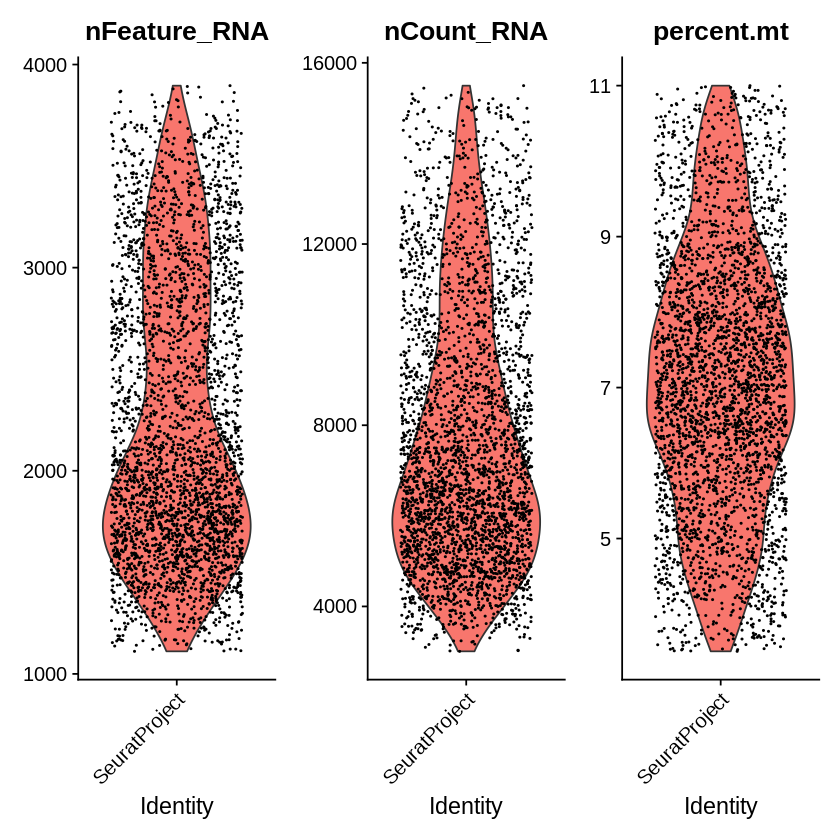

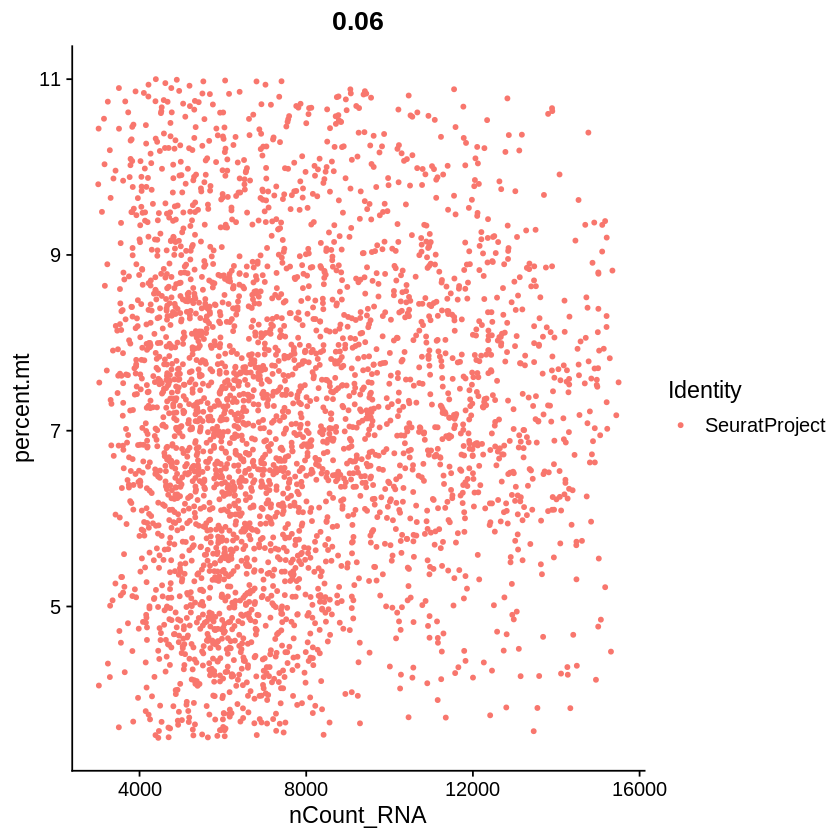

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,3595679,192.1,5643014,301.4,5643014,301.4
Vcells,50183402,382.9,83592995,637.8,73044397,557.3


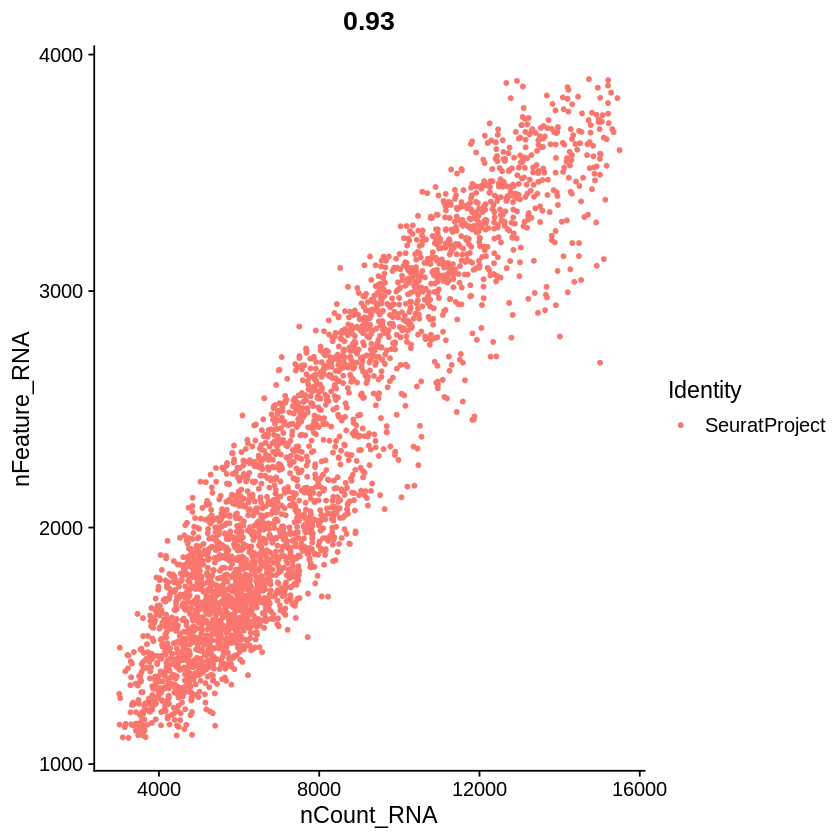

In [ ]:
su1.f <- subset(su1, subset = 
                nFeature_RNA > 1100 &
                nFeature_RNA < 3900 &
                percent.mt < 11 &
                nCount_RNA < 15500 &
                nCount_RNA > 3000)
VlnPlot(su1.f, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol = 3, pt.size = 0.2)

FeatureScatter(su1.f, feature1 = "nCount_RNA", feature2 = "percent.mt")
FeatureScatter(su1.f, feature1 = "nCount_RNA", feature2 = "nFeature_RNA")

rm(su1)
gc()

In [6]:
dim(su1.f)

[1] 36601  3233

> Gets rid of ~ 800 cells

## Plot for su2

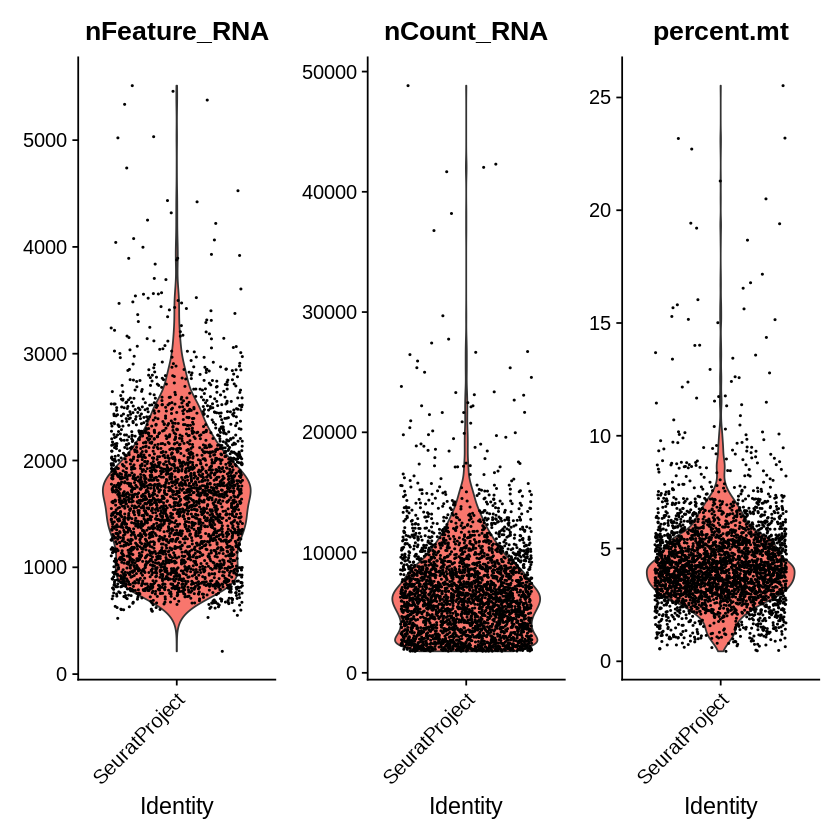

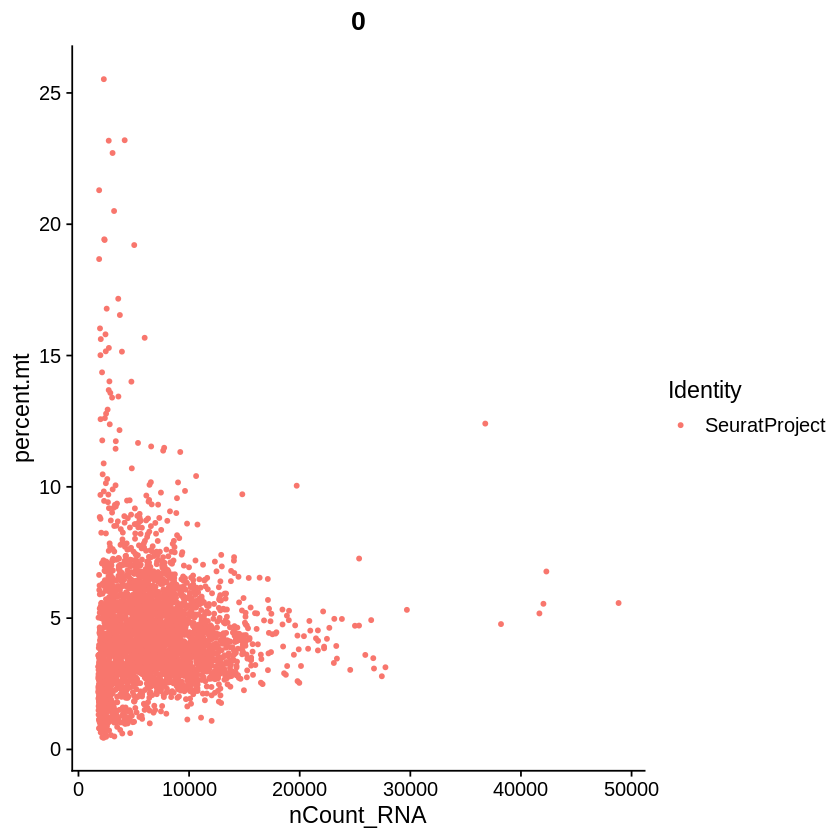

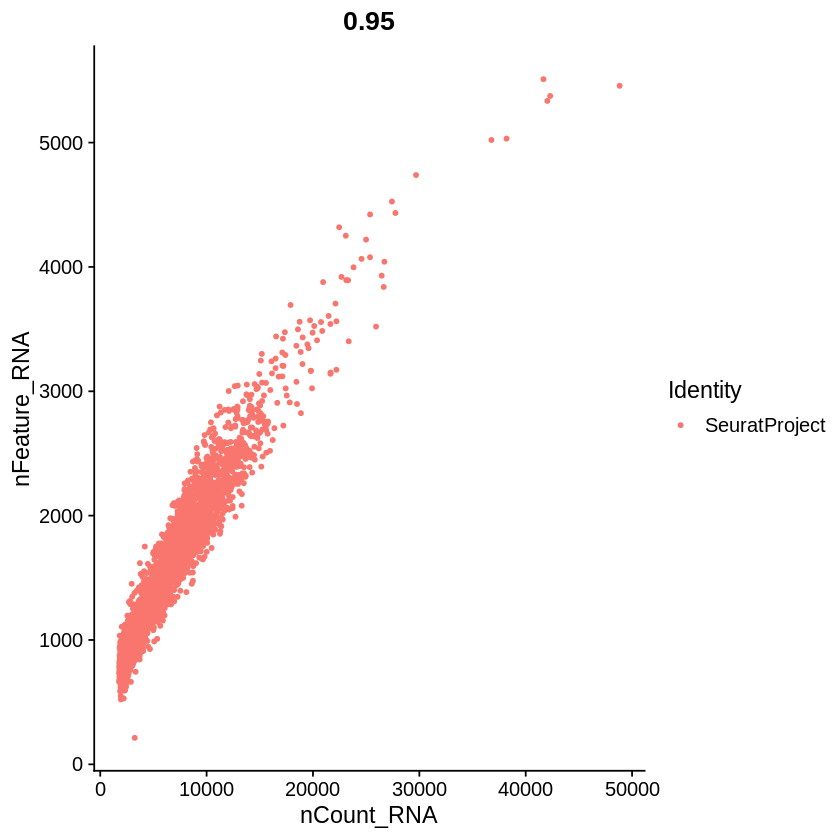

In [7]:
VlnPlot(su2, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol = 3, pt.size = 0.2)
FeatureScatter(su2, feature1 = "nCount_RNA", feature2 = "percent.mt")
FeatureScatter(su2, feature1 = "nCount_RNA", feature2 = "nFeature_RNA")

> Gene count (nFeature) have tails on both ends; UMI count (nCount) has a long tail on top; mito % has a long tail on top;  
A number of cells have low UMI count and high mito %. Also some with high UMI and low mito %. Should be removed;  
A high number of cells have high UMI count and gene count. Should be removed.

## Filtering su2

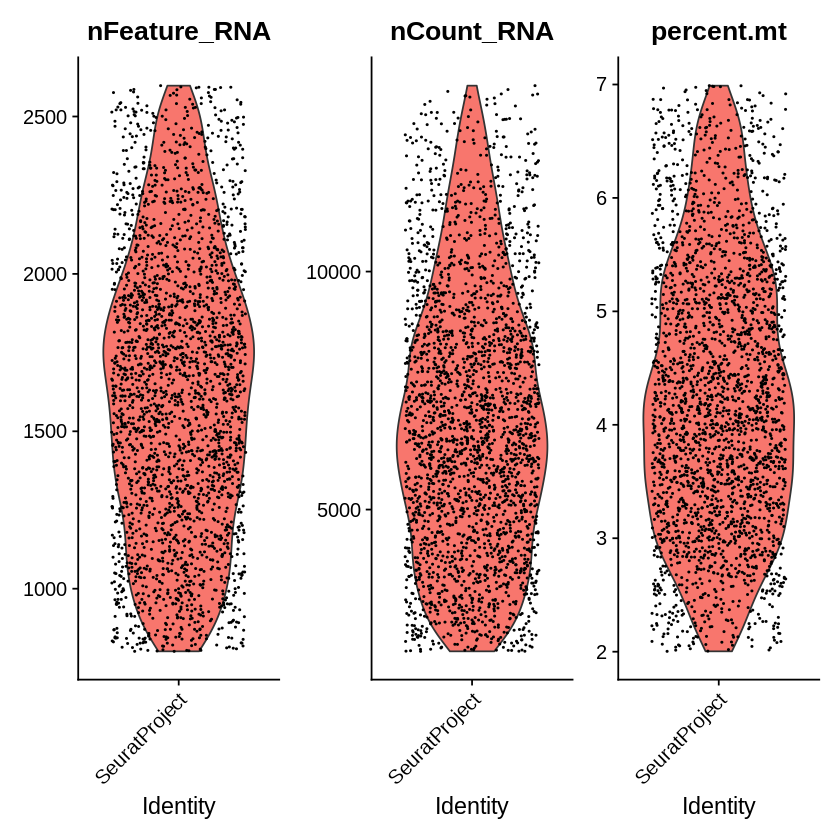

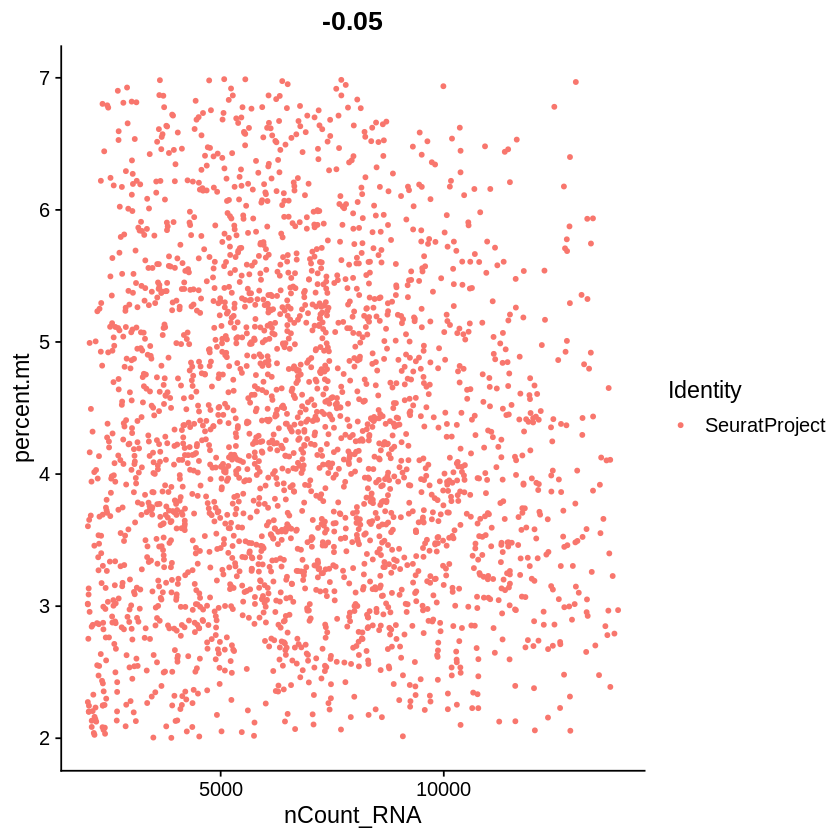

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,3602137,192.4,5643014,301.4,5643014,301.4
Vcells,62539607,477.2,100391594,766.0,80400750,613.5


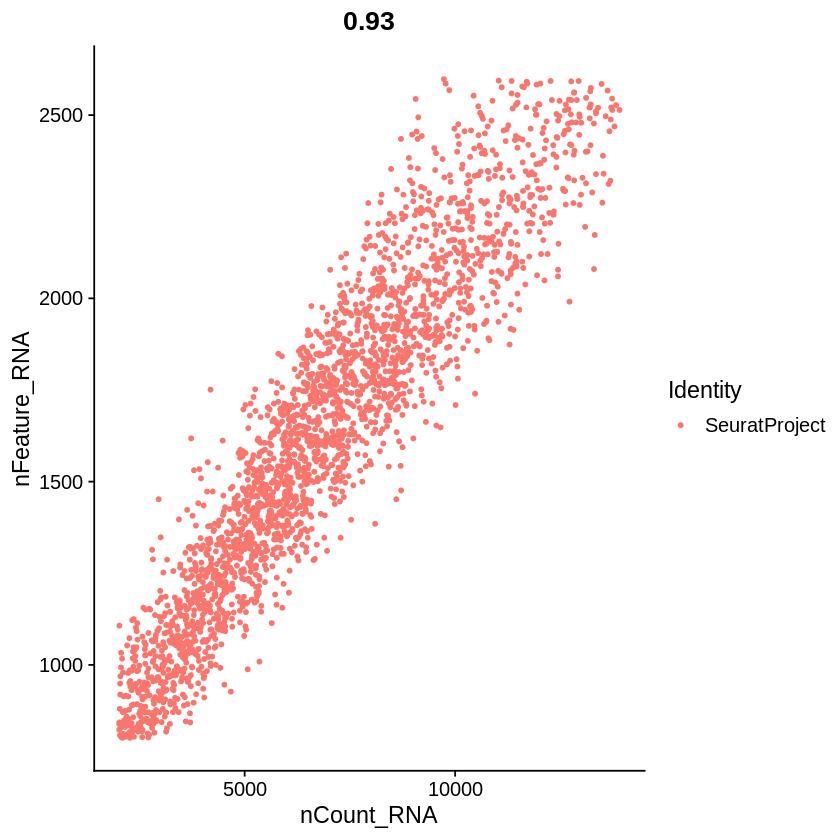

In [ ]:
su2.f <- subset(su2, subset = 
                nFeature_RNA > 800 &
                nFeature_RNA < 2600 &
                percent.mt < 7 &
                nCount_RNA < 14000 &
                nCount_RNA > 2000)
VlnPlot(su2.f, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol = 3, pt.size = 0.2)

FeatureScatter(su2.f, feature1 = "nCount_RNA", feature2 = "percent.mt")
FeatureScatter(su2.f, feature1 = "nCount_RNA", feature2 = "nFeature_RNA")

rm(su2)
gc()

In [9]:
dim(su2.f)

[1] 24670  2517

Removed ~800 cells

# SCTransform

In [10]:
su1.f <- SCTransform(object = su1.f, vars.to.regress = "percent.mt")
su2.f <- SCTransform(object = su2.f, vars.to.regress = "percent.mt")

Calculating cell attributes from input UMI matrix: log_umi

Variance stabilizing transformation of count matrix of size 17105 by 3233

Model formula is y ~ log_umi

Get Negative Binomial regression parameters per gene

Using 2000 genes, 3233 cells



  |======================================================================| 100%


Found 80 outliers - those will be ignored in fitting/regularization step


Second step: Get residuals using fitted parameters for 17105 genes



  |======================================================================| 100%


Computing corrected count matrix for 17105 genes



...

Second step: Get residuals using fitted parameters for 16043 genes



  |======================================================================| 100%


Computing corrected count matrix for 16043 genes



  |======================================================================| 100%


Calculating gene attributes

Wall clock passed: Time difference of 27.02412 secs

Determine variable features

Place corrected count matrix in counts slot

Regressing out percent.mt

Centering data matrix

Set default assay to SCT



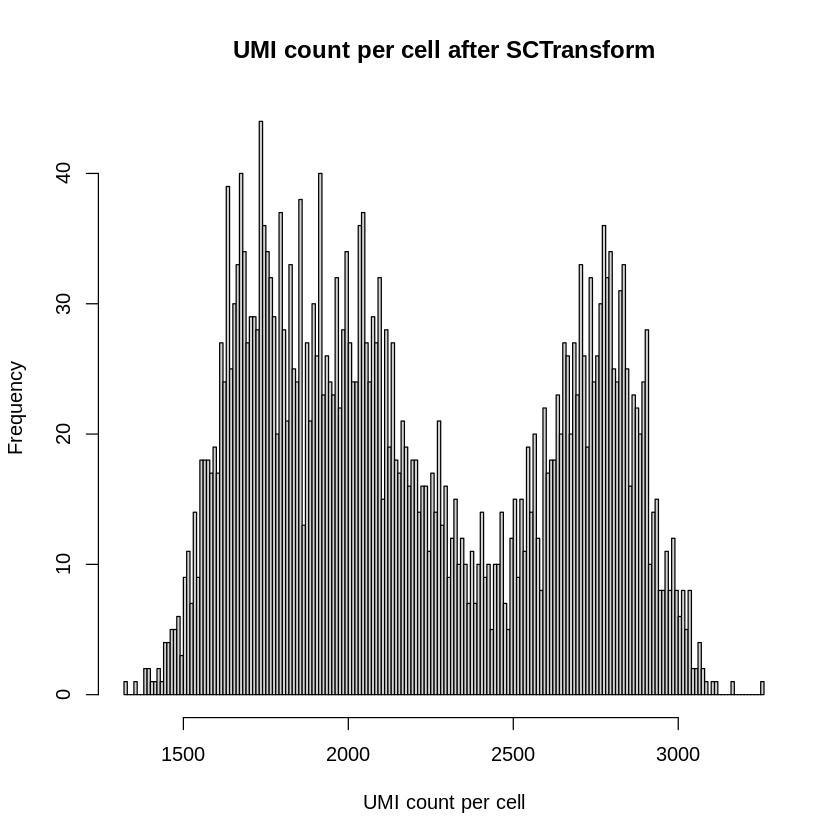

In [15]:
hist(colSums(su1.f@assays$SCT@data),
     breaks = 150,
     main = "UMI count per cell after SCTransform",
     xlab = "UMI count per cell")

> Bimodal distribution.

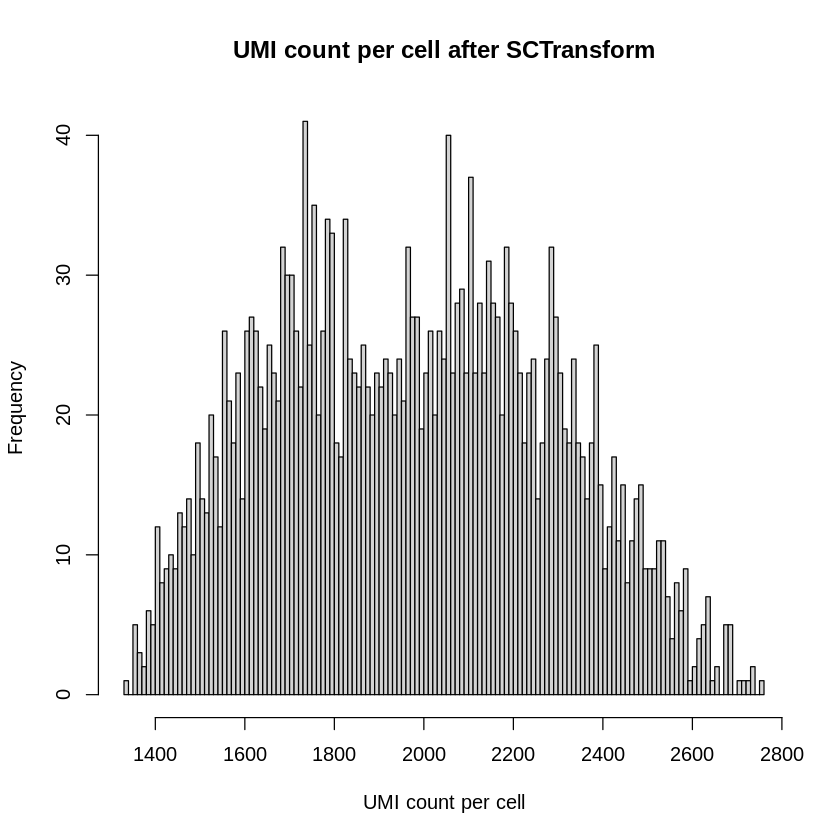

In [16]:
hist(colSums(su2.f@assays$SCT@data),
     breaks = 150,
     main = "UMI count per cell after SCTransform",
     xlab = "UMI count per cell")



> Approximately normal distribution

# Linear Dimension Reduction w/ PCA

## Run PCA for sample 1 and sample 2

In [11]:
su1.f <- RunPCA(su1.f,
                Assay = "SCT",
                rev.pca = TRUE, # Since we have a gene x cell matrix
                verbose = FALSE)

su2.f <- RunPCA(su2.f,
                Assay = "SCT",
                rev.pca = TRUE,
                verbose = FALSE)

## A function to get the Scree plot

In [18]:
# Jackstraw cannot be run on SCTransform-normalized data
# Make a Scree plot
makeScree <- function(seuratObject,numPCs){
    result <- seuratObject@reductions
    sdv <- result$pca@stdev[1:numPCs]
    names <- attributes(result$pca@cell.embeddings)[[2]][2] %>% unlist
    names <- names[1:numPCs]
    
    scree <- as.data.frame(list(names,sdv^2/sum(sdv^2)))
    colnames(scree) <- c("PC","Percent")
    scree$PC <- factor(scree$PC,levels = scree$PC)

    ggplot(scree, aes(x = PC,y = Percent,group=1)) +
    geom_line(color="grey") +
    geom_point() +
    ggtitle("Scree Plot") +
    xlab("Principal Components") +
    ylab("Percent Variance Explained") +
    theme_minimal()
    }

## Plot for sample 1

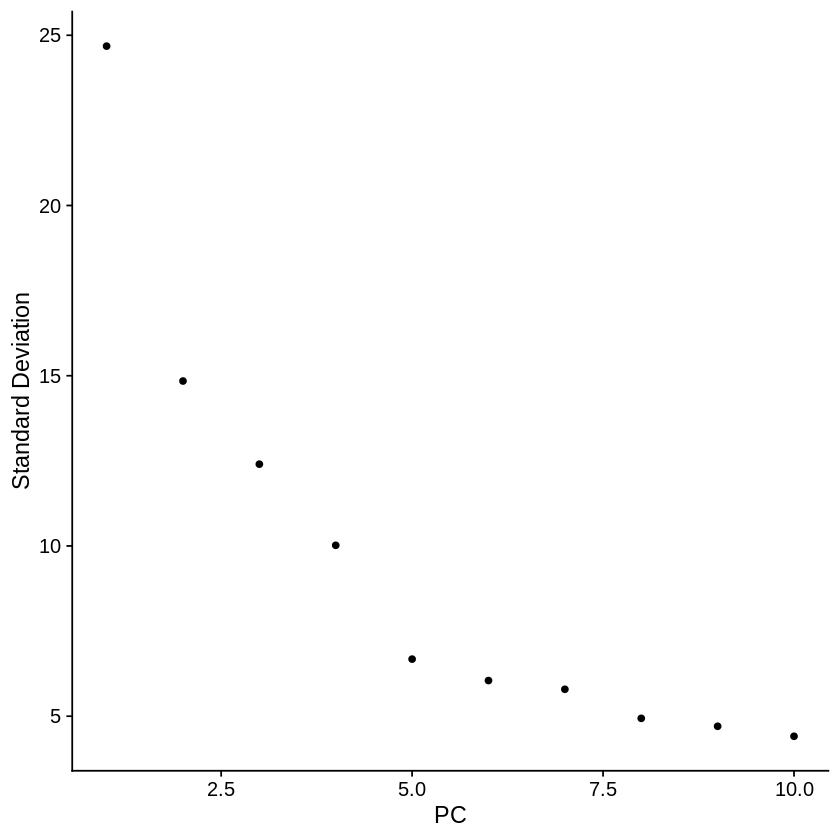

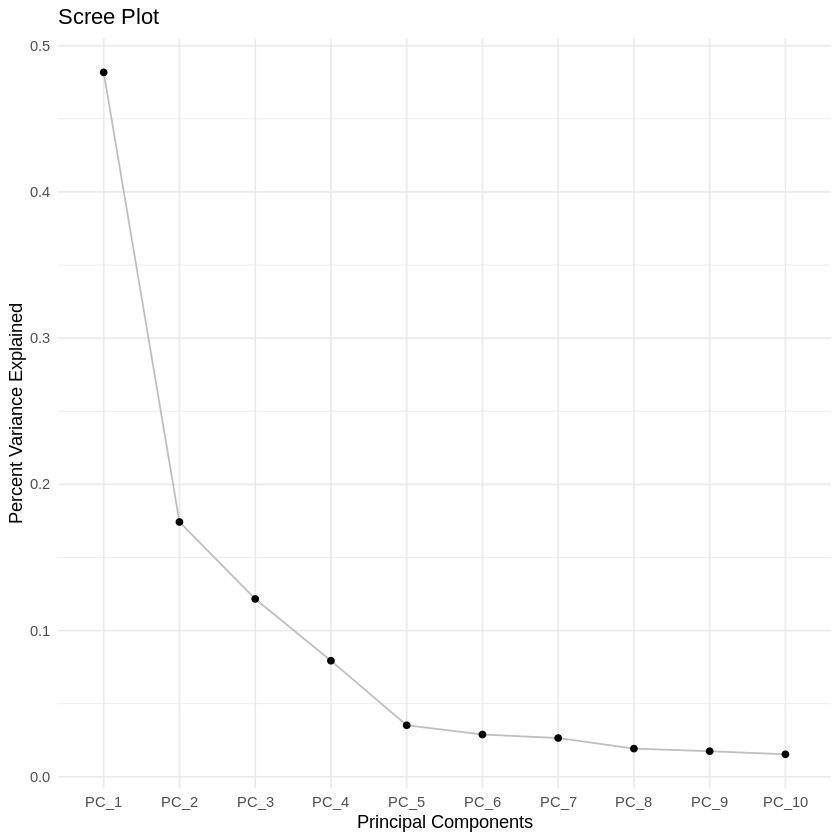

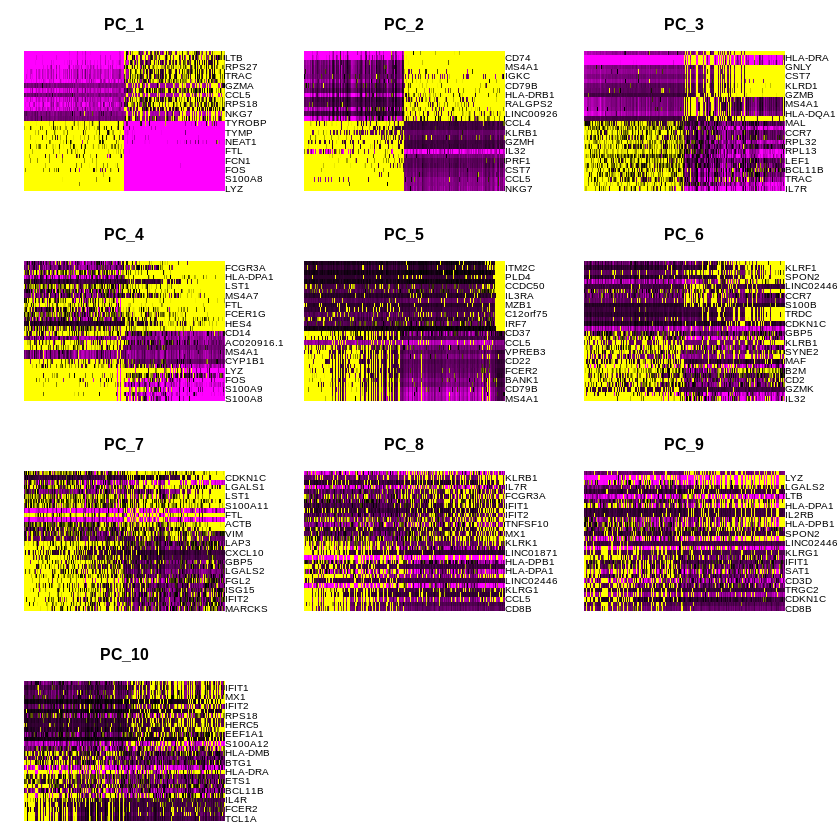

In [19]:
ndims <- 10

ElbowPlot(su1.f, ndims= ndims)

makeScree(su1.f,numPCs=ndims)

DimHeatmap(su1.f, dims = 1:ndims, cells = 500, balanced = TRUE)

## Plot for sample 2

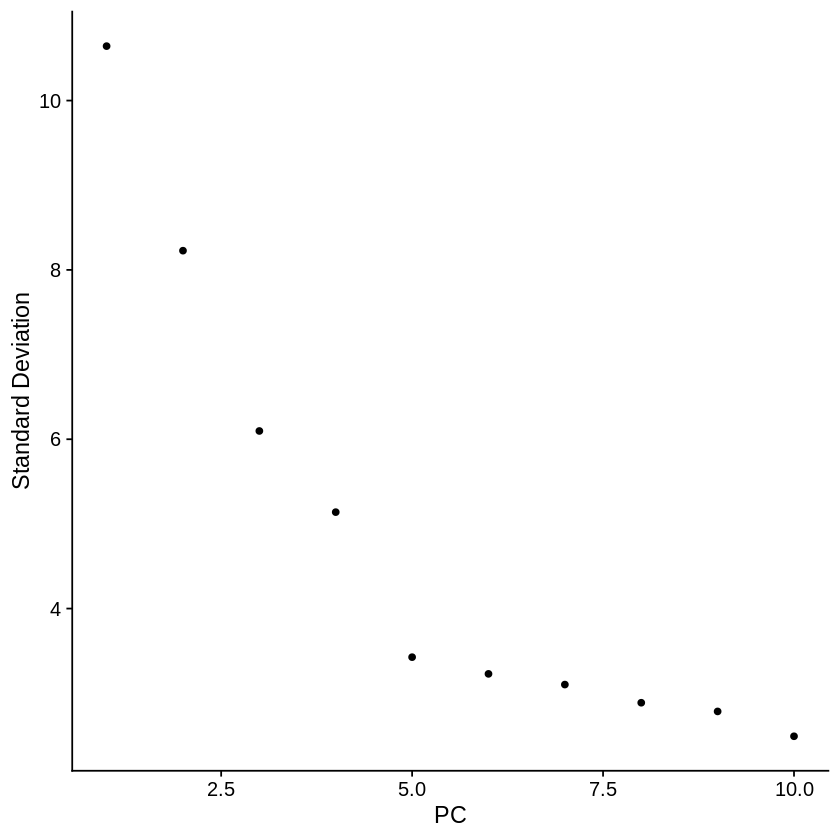

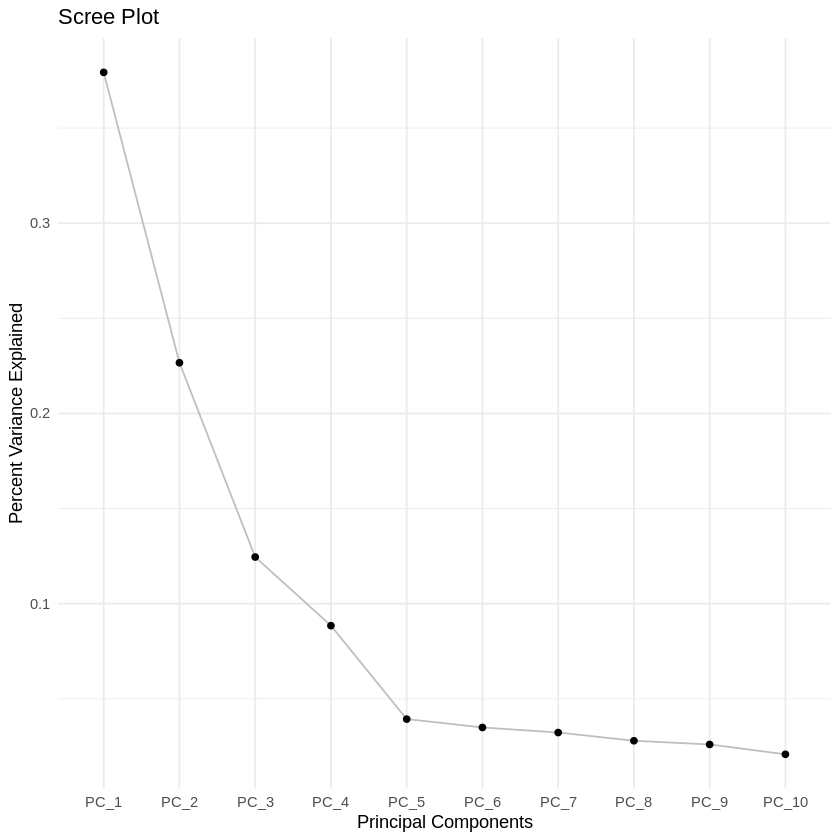

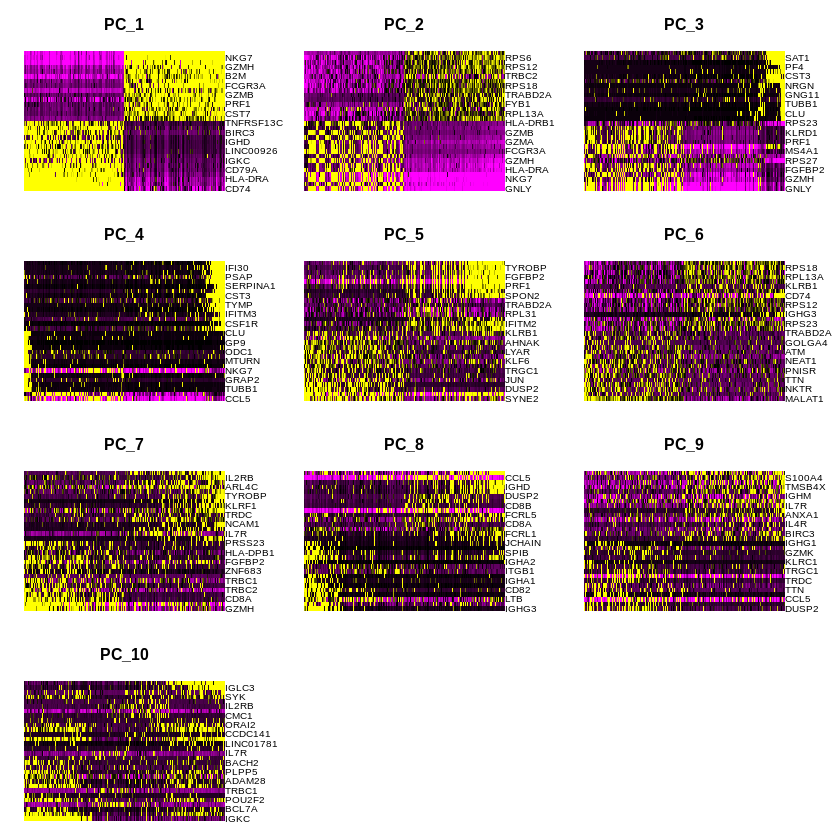

In [20]:
ndims <- 10

ElbowPlot(su2.f, ndims= ndims)

makeScree(su2.f,numPCs=ndims)

DimHeatmap(su2.f, dims = 1:ndims, cells = 500, balanced = TRUE)

> After reviewing the plots, try keeping 5 PCs for both sample 1 and sample 2. Usually should keep more but would take too long to run for a demo.

# Non-Linear Dimension Reduction w/ UMAP

## UMAP for su1

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”


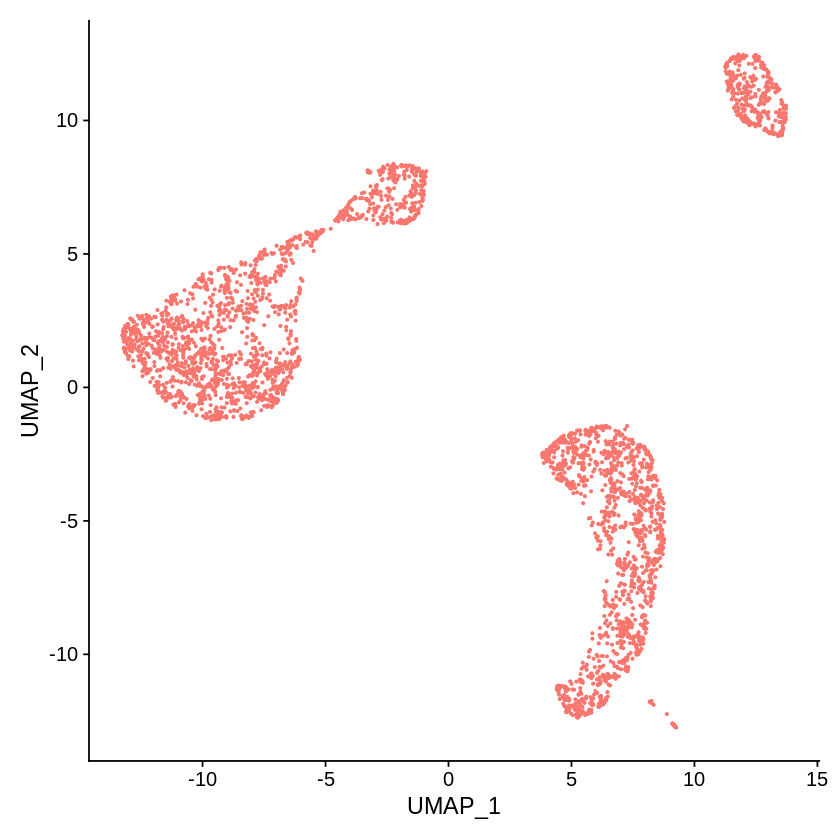

In [12]:
ndims <- 5
su1.f <- RunUMAP(su1.f, 
                 dims = 1:ndims, 
                 n.neighbors = 35L, 
                 min.dist = 0.2,
                 verbose=FALSE)
DimPlot(su1.f, reduction = "umap")+NoLegend()

# The results are saved along with PCA dimension reduction

> Tried many combinations and always showed 4 obvious chunks

## UMAP for su2

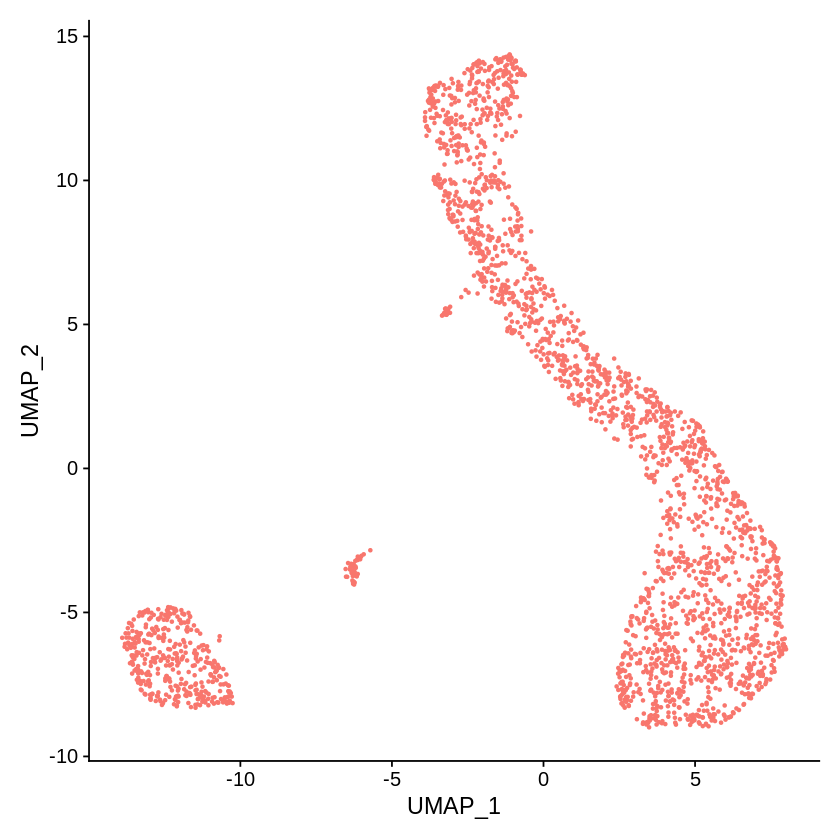

In [13]:
ndims <- 5
su2.f <- RunUMAP(su2.f, 
                 dims = 1:ndims, 
                 n.neighbors = 35L, 
                 min.dist = 0.3,
                 verbose=FALSE)
DimPlot(su2.f, reduction = "umap")+NoLegend()

> One large chunck and one small chuck.

# Doublet Removal

## Identify doublets

In [ ]:
library(DoubletFinder)

> A function to identify doublets in the data  
Doublet means 2 cells in one vesicle

In [15]:
Find_doublet <- function(data,numPCs){
  # Find optimal pK
  sweep.res.list <- paramSweep_v3(data, PCs = 1:numPCs, sct = T) # 若使用SCT方法 标准化则'sct=T'
  sweep.stats <- summarizeSweep(sweep.res.list, GT = FALSE)
  bcmvn <- find.pK(sweep.stats)
  p<-as.numeric(as.vector(bcmvn[bcmvn$MeanBC==max(bcmvn$MeanBC),]$pK))
  
  # Expected doublet rate; 0.05 is a good one
  homotypic.prop <- modelHomotypic(data@meta.data$seurat_clusters) #可使用注释好的细胞类型
  Doubletrate <- 0.05
  nExp_poi <- round(Doubletrate*ncol(data))
  nExp_poi.adj <- round(nExp_poi*(1-homotypic.prop))

  # Identify doublets
  data <- doubletFinder_v3(data, PCs = 1:numPCs, pN = 0.25, pK = p, nExp = nExp_poi.adj, reuse.pANN = FALSE, sct = T)
  colnames(data@meta.data)[ncol(data@meta.data)] = "doublet_info"
  return(data)
}

Loading required package: fields

Loading required package: spam

Spam version 2.9-0 (2022-07-11) is loaded.
Type 'help( Spam)' or 'demo( spam)' for a short introduction 
and overview of this package.
Help for individual functions is also obtained by adding the
suffix '.spam' to the function name, e.g. 'help( chol.spam)'.


Attaching package: ‘spam’


The following object is masked from ‘package:Matrix’:

    det


The following objects are masked from ‘package:base’:

    backsolve, forwardsolve


Loading required package: viridis

Loading required package: viridisLite


Try help(fields) to get started.


Attaching package: ‘fields’


The following object is masked from ‘package:psych’:

    describe




[1] "Creating artificial doublets for pN = 5%"


Loading required package: sctransform



[1] "Creating Seurat object..."
[1] "Running SCTransform..."


Calculating cell attributes from input UMI matrix: log_umi

Variance stabilizing transformation of count matrix of size 17358 by 3403

Model formula is y ~ log_umi

Get Negative Binomial regression parameters per gene

Using 2000 genes, 3403 cells



...

  |======================================================================| 100%


Calculating gene attributes

Wall clock passed: Time difference of 1.052067 mins

Determine variable features

Place corrected count matrix in counts slot

Centering data matrix

Set default assay to SCT



[1] "Running PCA..."


PC_ 1 
Positive:  LYZ, S100A9, S100A8, CTSS, FOS, VCAN, MNDA, FTL, FCN1, CST3 
	   FGL2, NEAT1, TYMP, AIF1, S100A12, TYROBP, DUSP1, FTH1, CYBB, PSAP 
	   IFI30, LST1, AC020656.1, SAT1, SERPINA1, DUSP6, S100A6, TNFSF10, MS4A6A, MARCKS 
Negative:  IL32, LTB, IL7R, RPS27, CD3D, TRAC, RPS12, TRBC2, CD3E, TRBC1 
	   RPS18, CD3G, RPL13, CCL5, RPL10, GZMA, BCL11B, NKG7, RPS29, RPS3 
	   RPL3, RPS27A, RPSA, PCED1B-AS1, GNLY, CTSW, LDHB, CD2, ARL4C, RPL32 
PC_ 2 
Positive:  IGHM, HLA-DRA, CD74, CD79A, MS4A1, IGKC, HLA-DQA1, CD79B, BANK1, IGHD 
	   HLA-DRB1, RALGPS2, HLA-DPB1, TCL1A, LINC00926, HLA-DPA1, VPREB3, TNFRSF13C, CD22, LINC02397 
	   BCL11A, FCER2, AFF3, NIBAN3, SPIB, HLA-DQB1, IGLC2, PAX5, CD37, LTB 
Negative:  NKG7, GNLY, CCL5, GZMA, CST7, KLRD1, PRF1, CTSW, FGFBP2, GZMH 
	   GZMB, HOPX, KLRB1, IL32, CCL4, KLRF1, SPON2, TRDC, GZMM, HCST 
	   CD247, KLRG1, CLIC3, IL2RB, LAIR2, KLRK1, ADGRG1, CD160, ARL4C, PTGDR 
PC_ 3 
Positive:  IL7R, TRAC, S100A8, RPS12, S100A9, BCL11B, TCF7, LDHB, 

[1] "Calculating PC distance matrix..."
[1] "Computing pANN..."
[1] "Classifying doublets.."


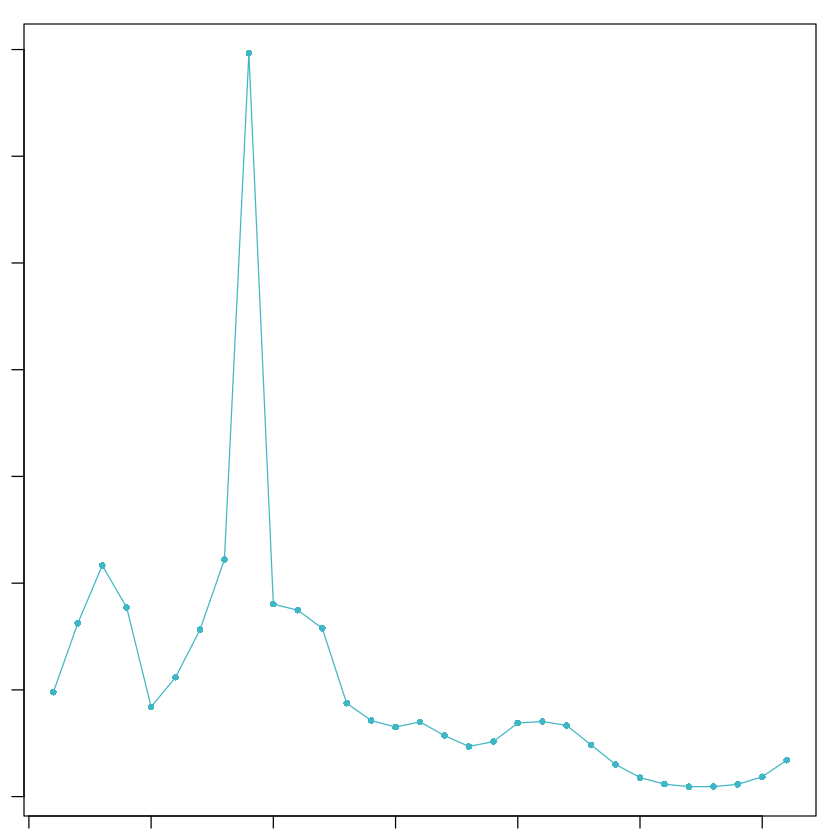

In [25]:
su1.f <- Find_doublet(su1.f,numPCs=5)

[1] "Creating artificial doublets for pN = 5%"
[1] "Creating Seurat object..."
[1] "Running SCTransform..."


Calculating cell attributes from input UMI matrix: log_umi

Variance stabilizing transformation of count matrix of size 16372 by 2649

Model formula is y ~ log_umi

Get Negative Binomial regression parameters per gene

Using 2000 genes, 2649 cells



  |======================================================================| 100%


Found 1 outliers - those will be ignored in fitting/regularization step


Second step: Get residuals using fitted parameters for 16372 genes



  |======================================================================| 100%


...

  |======================================================================| 100%


Calculating gene attributes

Wall clock passed: Time difference of 43.00657 secs

Determine variable features

Place corrected count matrix in counts slot

Centering data matrix

Set default assay to SCT



[1] "Running PCA..."


PC_ 1 
Positive:  GNLY, NKG7, CCL5, GZMH, B2M, GZMA, FGFBP2, ARL4C, FCGR3A, TMSB4X 
	   GZMB, PRF1, KLRD1, S100A4, IFITM2, CST7, ITGB2, SYNE2, ADGRG1, RUNX3 
	   TYROBP, IFITM1, SPN, HLA-B, EFHD2, KLRK1, TRBC1, SRGN, SYNE1, SPON2 
Negative:  CD74, IGHM, HLA-DRA, MS4A1, IGKC, CD79A, HLA-DQB1, CD79B, IGLC2, CD22 
	   LINC00926, IGHD, HLA-DQA1, TNFRSF13C, BANK1, RALGPS2, BIRC3, HLA-DRB1, HLA-DMB, SWAP70 
	   HLA-DPA1, NIBAN3, MEF2C, TCL1A, HLA-DPB1, PAX5, FCRL5, HLA-DRB5, IL4R, MARCH1 
PC_ 2 
Positive:  GNLY, NKG7, CCL5, CD74, GZMH, IGHM, HLA-DRA, FCGR3A, FGFBP2, GZMA 
	   MS4A1, GZMB, PRF1, IGKC, KLRD1, HLA-DQB1, TYROBP, CD79A, CST7, HLA-DPB1 
	   HLA-DRB1, HLA-DPA1, ADGRG1, HLA-DQA1, EFHD2, RUNX3, CD79B, SPON2, TMSB4X, B2M 
Negative:  IL7R, TPT1, RPS6, RPS12, EEF1A1, RPL34, RPS18, RPL13A, LTB, TRABD2A 
	   FYB1, MAL, TRBC2, RPS23, RPS27, CAMK4, IL6R, AQP3, ZFP36L2, RNF157 
	   CHRM3-AS2, LRRN3, NUCB2, INPP4B, FAM13A, TSHZ2, SLC16A10, EPHA1-AS1, MORN3, TXNIP 
PC_ 3 
Positive:  GNLY, NKG7

[1] "Calculating PC distance matrix..."
[1] "Computing pANN..."
[1] "Classifying doublets.."


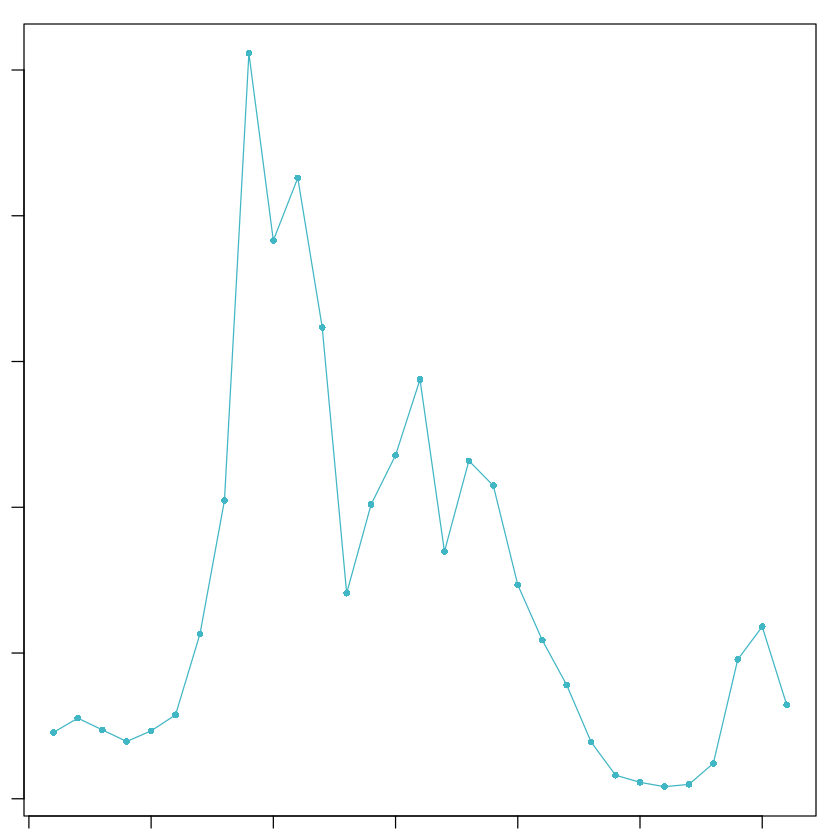

In [26]:
su2.f <- Find_doublet(su2.f,numPCs=5)

## Look at locations of doublets

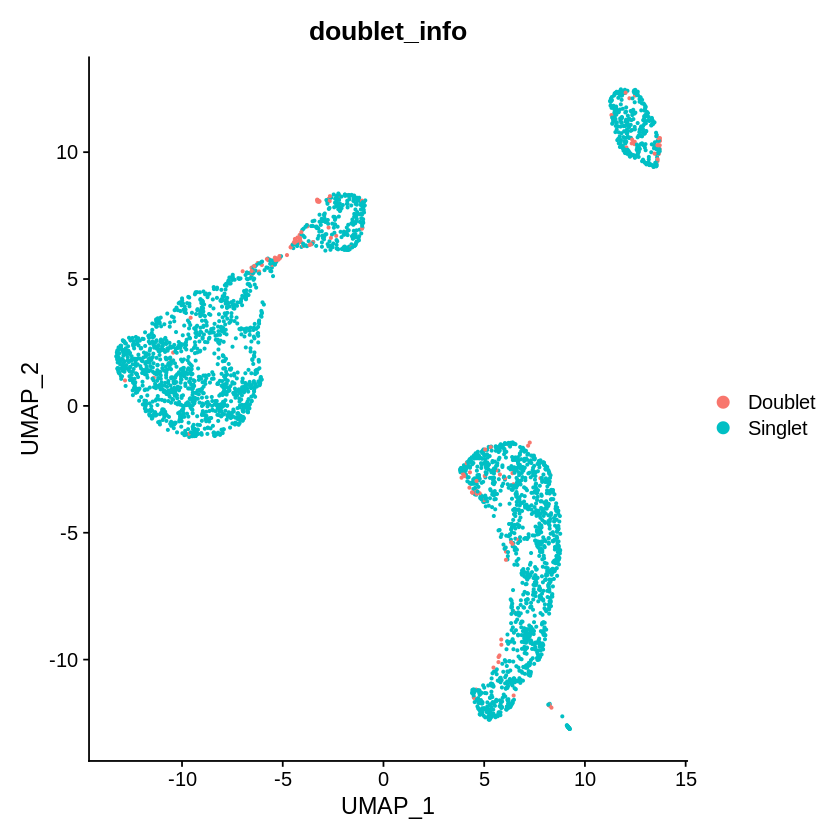

In [27]:
DimPlot(su1.f, reduction = "umap", group.by = "doublet_info")

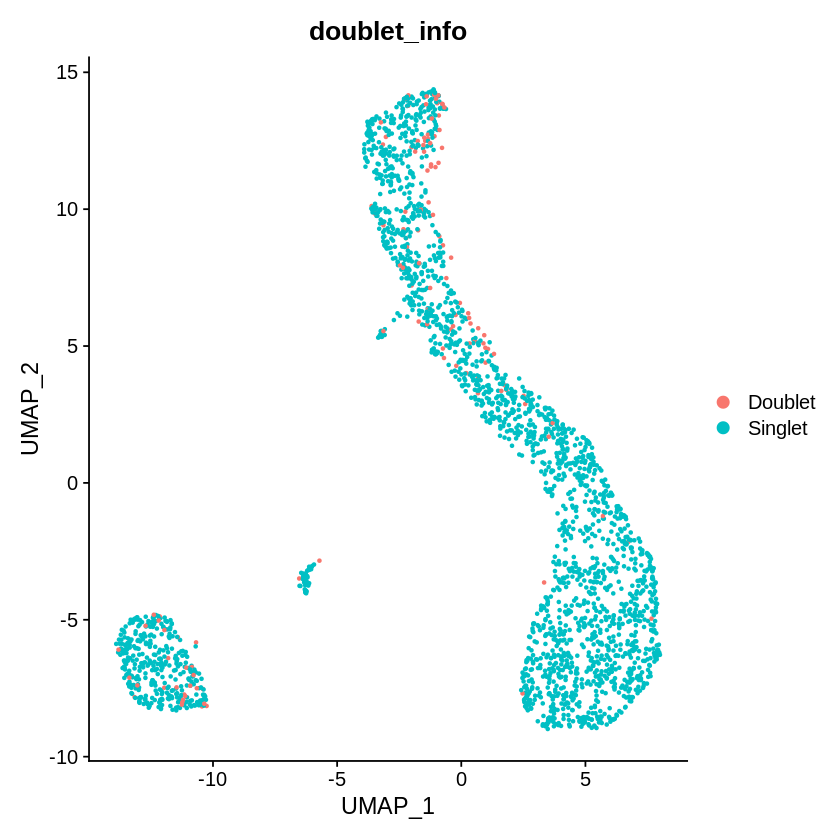

In [28]:
DimPlot(su2.f, reduction = "umap", group.by = "doublet_info")

> So there are doublets in every cluster, but all located on the perimeter. Good to know.

## Get singlets from result

In [29]:
su1.f <- subset(su1.f,subset=doublet_info=="Singlet")
su2.f <- subset(su2.f,subset=doublet_info=="Singlet")

In [30]:
dim(su1.f)
dim(su2.f)

[1] 17105  3071

[1] 16043  2391

> Around 100-200 cells are removed in each sample. Poor cells.

## Do SCTransform and dimension reduction again for the reduced sample

### For su1

Calculating cell attributes from input UMI matrix: log_umi

Variance stabilizing transformation of count matrix of size 16918 by 3071

Model formula is y ~ log_umi

Get Negative Binomial regression parameters per gene

Using 2000 genes, 3071 cells



  |======================================================================| 100%


Found 101 outliers - those will be ignored in fitting/regularization step


Second step: Get residuals using fitted parameters for 16918 genes



  |======================================================================| 100%


Computing corrected count matrix for 16918 genes



  |======================================================================| 100%


Calculating gene attributes

Wall clock passed: Time difference of 43.44328 secs

Determine variable features

Place corrected count matrix in counts slot

Regressing out percent.mt

Centering data matrix

Set default assay to SCT



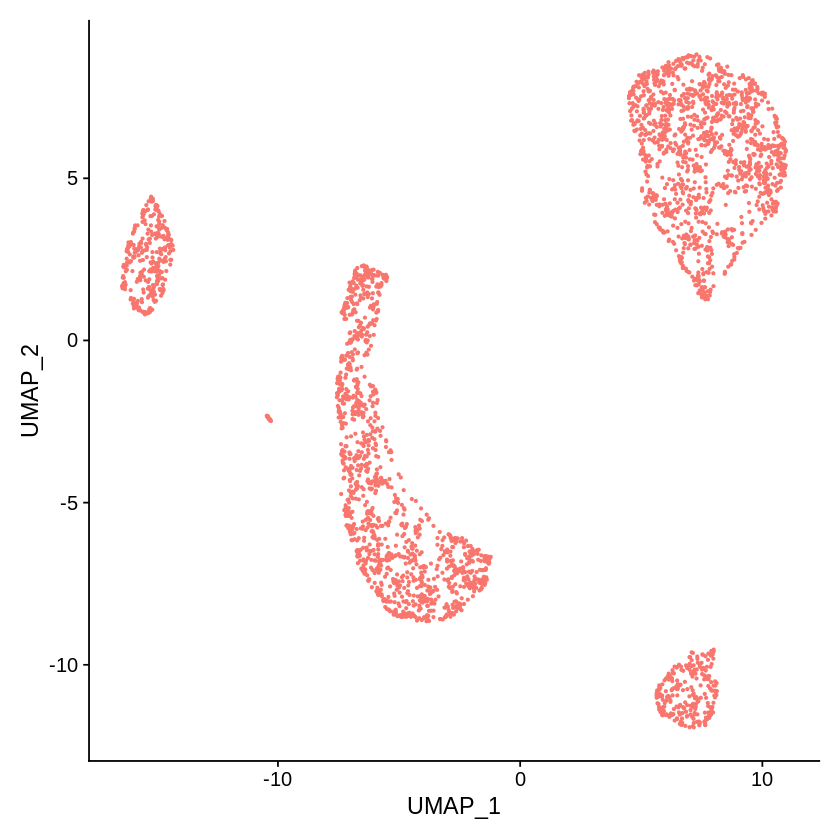

In [31]:
su1.f <- SCTransform(object = su1.f, vars.to.regress = "percent.mt")
su1.f <- RunPCA(su1.f,
                Assay = "SCT",
                rev.pca = TRUE, # Since we have a gene x cell matrix
                verbose = FALSE)
ndims <- 5
su1.f <- RunUMAP(su1.f, 
                 dims = 1:ndims, 
                 n.neighbors = 35L, 
                 min.dist = 0.2,
                 verbose=FALSE)
DimPlot(su1.f, reduction = "umap")+NoLegend()

### For su2

Calculating cell attributes from input UMI matrix: log_umi

Variance stabilizing transformation of count matrix of size 15885 by 2391

Model formula is y ~ log_umi

Get Negative Binomial regression parameters per gene

Using 2000 genes, 2391 cells



  |======================================================================| 100%


Found 1 outliers - those will be ignored in fitting/regularization step


Second step: Get residuals using fitted parameters for 15885 genes



  |======================================================================| 100%


Computing corrected count matrix for 15885 genes



  |======================================================================| 100%


Calculating gene attributes

Wall clock passed: Time difference of 27.03953 secs

Determine variable features

Place corrected count matrix in counts slot

Regressing out percent.mt

Centering data matrix

Set default assay to SCT



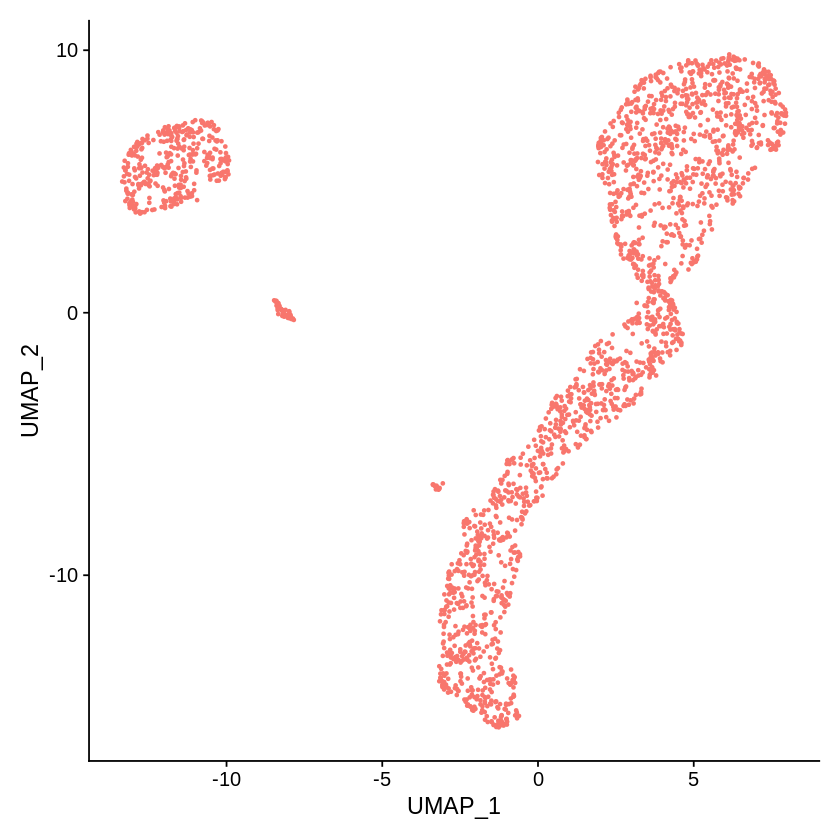

In [32]:
su2.f <- SCTransform(object = su2.f, vars.to.regress = "percent.mt")
su2.f <- RunPCA(su2.f,
                Assay = "SCT",
                rev.pca = TRUE,
                verbose = FALSE)
ndims <- 5
su2.f <- RunUMAP(su2.f, 
                 dims = 1:ndims, 
                 n.neighbors = 35L, 
                 min.dist = 0.3,
                 verbose=FALSE)
DimPlot(su2.f, reduction = "umap")+NoLegend()

# Merge samples

## Combine the data with merge()

### Merge

In [33]:
su3 <- merge(x=su1.f,
             y=su2.f)
Group <- c(rep("su1.f",dim(su1.f)[2]),rep("su2.f",dim(su2.f)[2])) # Add group name to identify original sample
su3 <- AddMetaData(su3, Group, col.name = "split") # Add group info to metadata

In [34]:
dim(su3)

[1] 18166  5462

### SCTransform

In [ ]:
# The SCTransform function needs to work on the RNA assay. 
# So you are not doing logs over and over again.
su3 <- SCTransform(object = su3,
                   vars.to.regress = "percent.mt")



Calculating cell attributes from input UMI matrix: log_umi

Variance stabilizing transformation of count matrix of size 19044 by 5462

Model formula is y ~ log_umi

Get Negative Binomial regression parameters per gene

Using 2000 genes, 5000 cells



  |======================================================================| 100%


Found 27 outliers - those will be ignored in fitting/regularization step


Second step: Get residuals using fitted parameters for 19044 genes



  |======================================================================| 100%


Computing corrected count matrix for 19044 genes



  |======================================================================| 100%


Calculating gene attributes

Wall clock passed: Time difference of 1.89974 mins

Determine variable features

Place corrected count matrix in counts slot

Regressing out percent.mt

Centering data matrix

Set default assay to SCT



In [36]:
dim(su3)

[1] 19044  5462

> When the data are merged more genes come out of feature selection/or maybe this is the wrong approach

### PCA

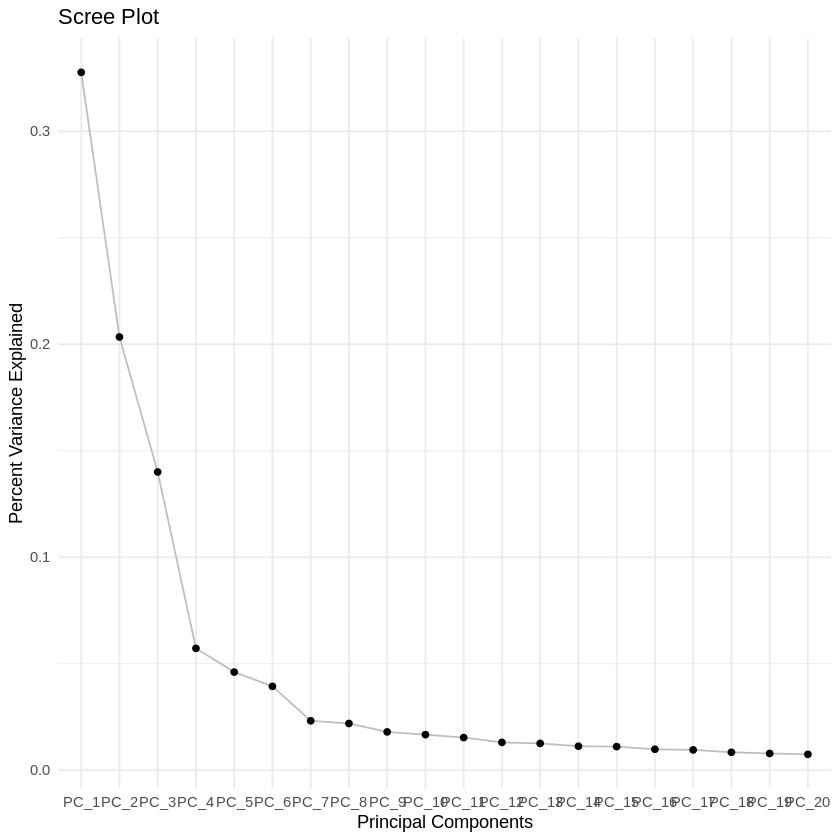

In [37]:
su3 <- RunPCA(su3,
              Assay = "SCT",
              rev.pca = TRUE,
              verbose = FALSE)
makeScree(su3,20)

> Keeping 7 PCs seem reasonable.

### UMAP

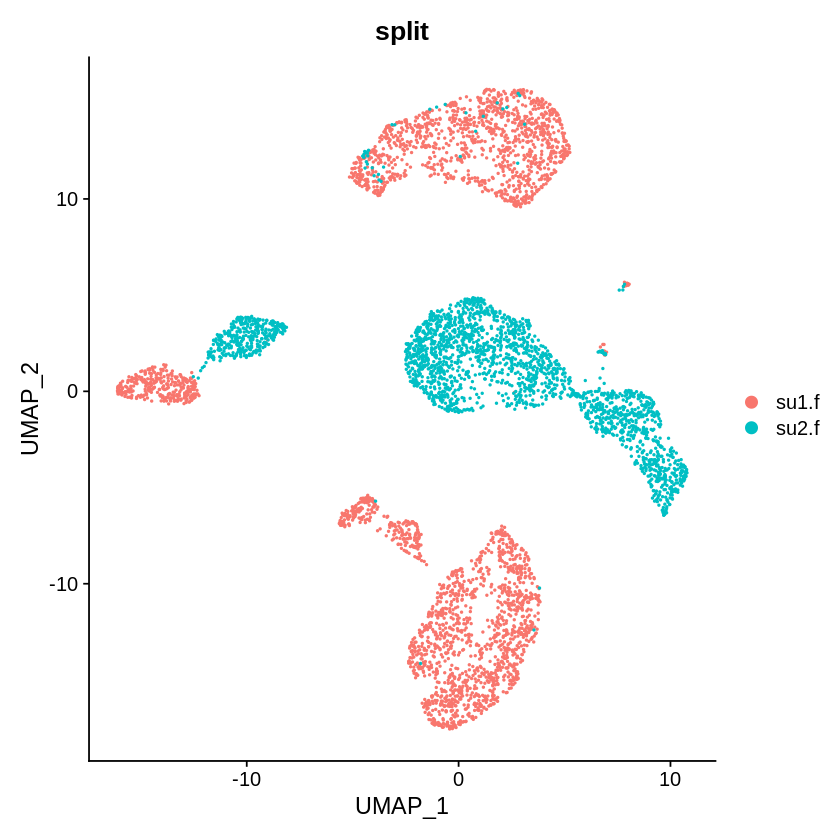

In [38]:
ndims <- 7
su3 <- RunUMAP(su3, 
               dims = 1:ndims, 
               reduction = "pca", # Defaults to pca; hence why previously not entered
               n.neighbors = 40L, 
               min.dist = 0.4,
               verbose=FALSE)
DimPlot(su3, 
        reduction = "umap",
        group.by = "split") 

> Bad merging

## Combine data using anchor

### Find the anchor

In [39]:
ndims <- 5 # 5 PCs were kept for su1.f and su2.f
sulist <- list(su1.f,su2.f)
su.anchors <- FindIntegrationAnchors(object.list = sulist, dims = 1:ndims)

Computing 2000 integration features

Scaling features for provided objects

Finding all pairwise anchors

Running CCA

Merging objects

Finding neighborhoods

Finding anchors

	Found 3852 anchors

Filtering anchors

	Retained 1745 anchors



### Combine using the anchors

In [40]:
su3_1 <- IntegrateData(anchorset = su.anchors, dims = 1:ndims) # Because 1+2=3
DefaultAssay(su3_1) <- "integrated"


Merging dataset 2 into 1

Extracting anchors for merged samples

Finding integration vectors

Finding integration vector weights

Integrating data



In [41]:
dim(su3_1)

[1] 2000 5462

> Lots of genes are removed!

### Scaling

In [42]:
su3_1 <- ScaleData(su3_1)

Centering and scaling data matrix



### PCA

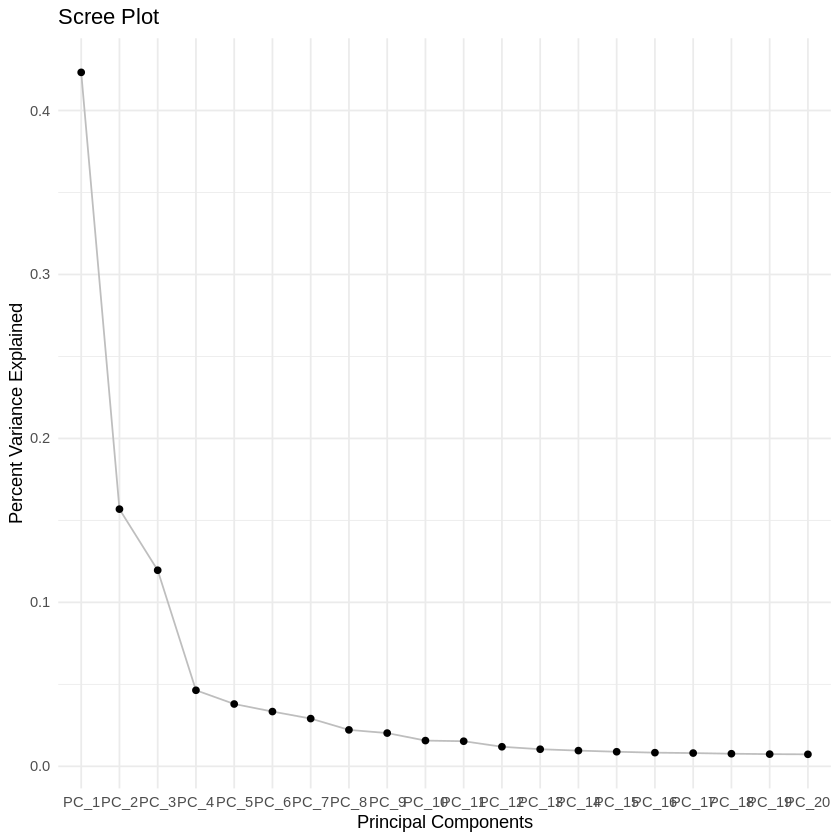

In [43]:
su3_1 <- RunPCA(su3_1,
                Assay = "SCT",
                rev.pca = TRUE,
                verbose = FALSE)
makeScree(su3_1,20)

> Keep 10 PCs

### UMAP

In [44]:
ndims <- 10
su3_1 <- RunUMAP(su3_1, 
                 dims = 1:ndims, 
                 reduction = "pca", # Defaults to pca; hence why previously not entered
                 n.neighbors = 40L, 
                 min.dist = 0.4,
                 verbose=FALSE)

In [45]:
su3_1@meta.data[grep("-1",rownames(su3_1@meta.data)),"split"] <- "su1.f"
su3_1@meta.data[grep("_N",rownames(su3_1@meta.data)),"split"] <- "su2.f"

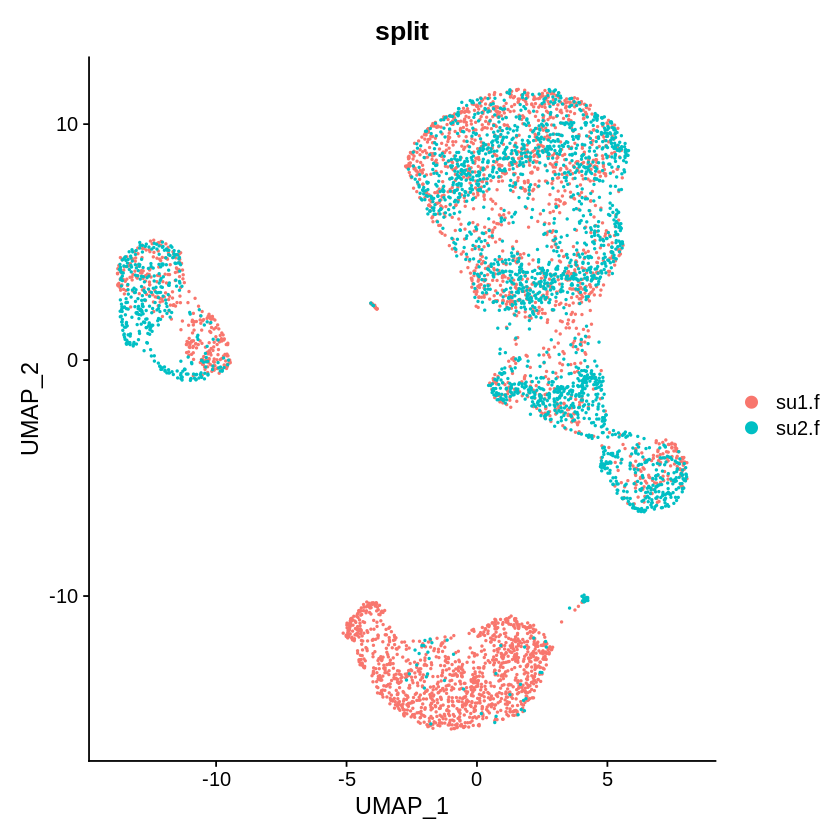

In [46]:
DimPlot(su3_1, 
        reduction = "umap",
        group.by = "split") 

> Good mixture. The two clusters of su2 overlap with the clusters of su1.

## Harmony

### Load the library

In [47]:
library(harmony)

Loading required package: Rcpp

Warning message:
“package ‘Rcpp’ was built under R version 4.1.3”


### Combine the data

In [48]:
su3_2 <- merge(x=su1.f,
               y=su2.f)
Group <- c(rep("su1.f",dim(su1.f)[2]),rep("su2.f",dim(su2.f)[2])) # Add group name to identify original sample
su3_2 <- AddMetaData(su3_2, Group, col.name = "split") # Add group info to metadata
DefaultAssay(su3_2) <- "RNA"

### Scale and Feature Selection

In [49]:
su3_2 <- ScaleData(su3_2, verbose = FALSE)
su3_2 <- FindVariableFeatures(su3_2, selection.method = "vst", nfeatures = 3000)

### PCA

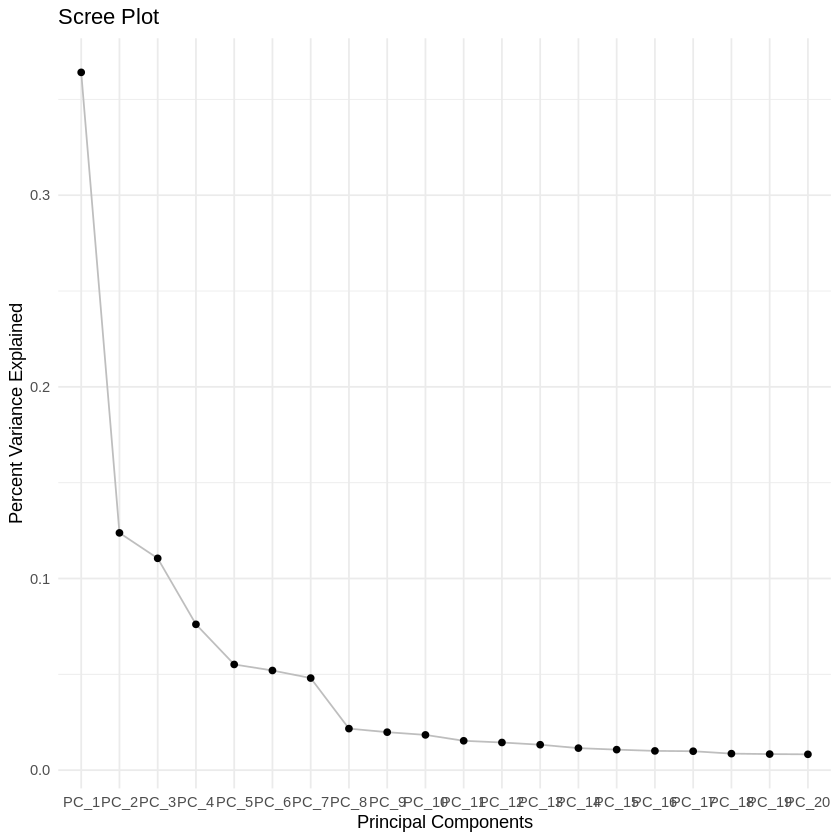

In [50]:
su3_2 <- RunPCA(su3_2,
                Assay = "SCT",
                rev.pca = TRUE,
                verbose = FALSE)
makeScree(su3_2,20)

> Keep 8 PCs this time

### Harmony

In [51]:
su3_2 <- RunHarmony(su3_2,dims = 1:8, "split",verbose = FALSE)

Warning message:
“Invalid name supplied, making object name syntactically valid. New object name is Seurat..ProjectDim.RNA.harmony; see ?make.names for more details on syntax validity”


> Harmony does not work if SCTransform is selected. Need to know why.

### UMAP

06:18:42 UMAP embedding parameters a = 0.9922 b = 1.112

06:18:42 Read 5462 rows and found 8 numeric columns

06:18:42 Using Annoy for neighbor search, n_neighbors = 30

06:18:42 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

06:18:43 Writing NN index file to temp file /tmp/Rtmp1GyXdZ/fileeb6943caf2

06:18:43 Searching Annoy index using 1 thread, search_k = 3000

06:18:45 Annoy recall = 100%

06:18:45 Commencing smooth kNN distance calibration using 1 thread

06:18:46 Initializing from normalized Laplacian + noise

06:18:46 Commencing optimization for 500 epochs, with 216968 positive edges

06:18:52 Optimization finished



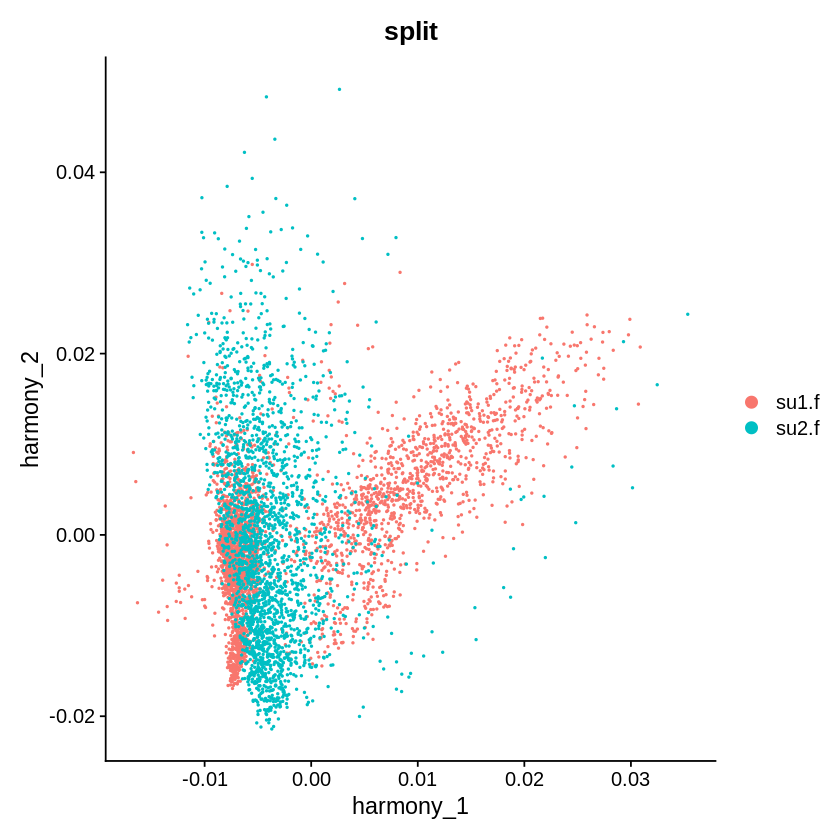

In [52]:
su3_2 <- RunUMAP(su3_2,reduction = "harmony", dims = 1:8)
DimPlot(su3_2, 
        reduction = "harmony",
        group.by = "split") 

> Cool overlap, but the right cluster of su1 has no overlap with su2. Probably this is the same cluster that was on the bottom of the previous UMAP plot.

# Clustering

## With Anchor Combined Data

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 5462
Number of edges: 174899

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9065
Number of communities: 12
Elapsed time: 0 seconds


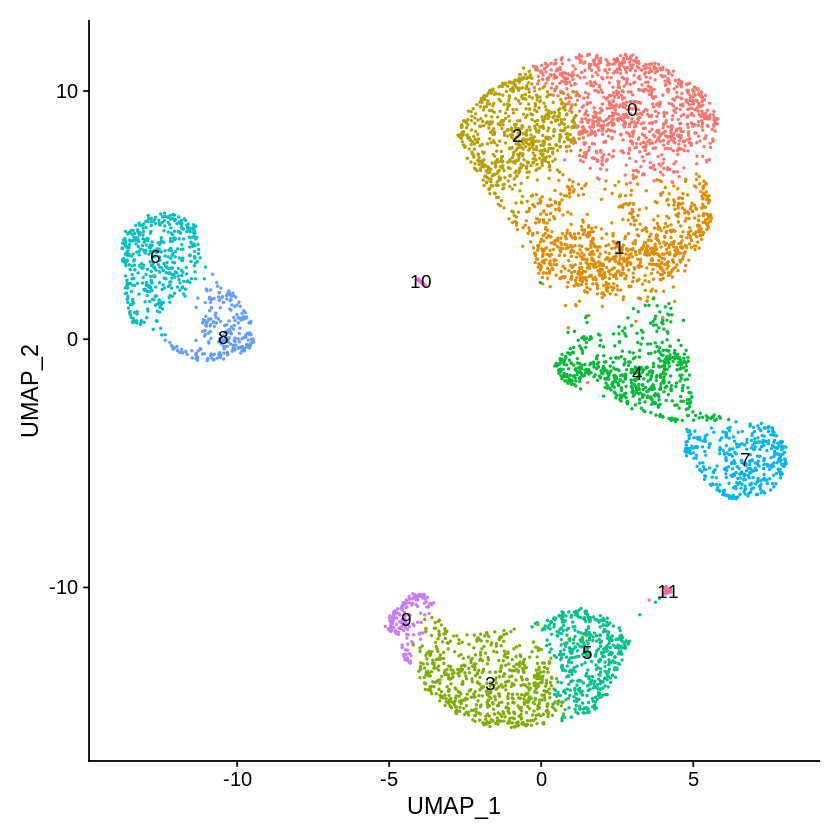

In [53]:
su3_1 <- FindNeighbors(su3_1, 
                       dims = 1:10, 
                       reduction = "pca")

su3_1 <- FindClusters(su3_1, 
                      resolution = 0.5)

DimPlot(su3_1, 
        reduction = "umap", 
        label=TRUE) + NoLegend()

> Pretty good cluster boundaries

## With Harmony Combined Data

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 5462
Number of edges: 163040

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9199
Number of communities: 13
Elapsed time: 0 seconds


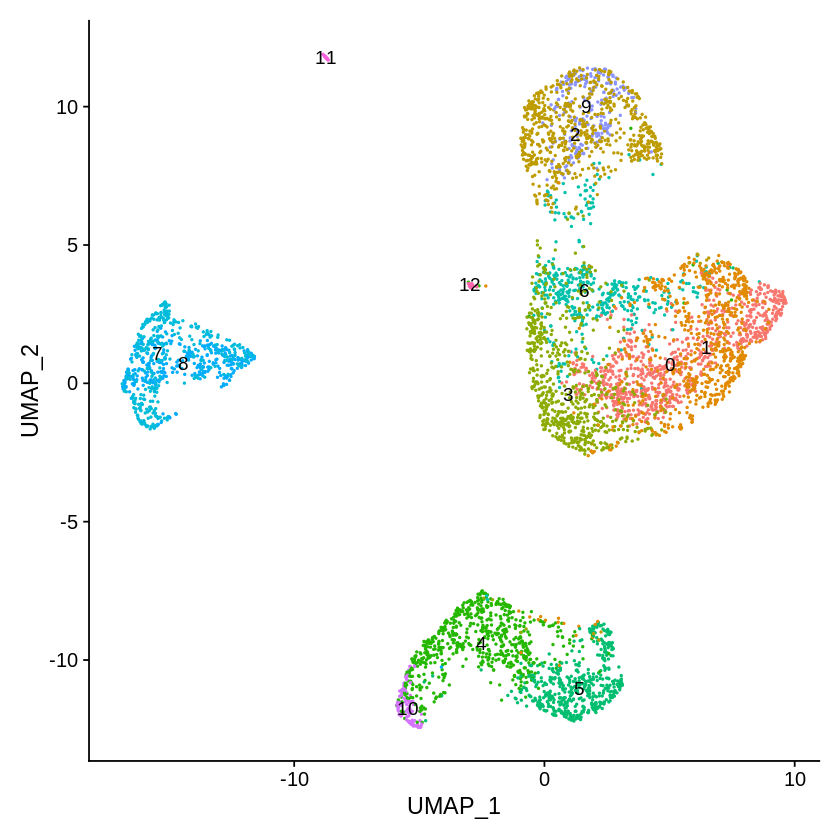

In [54]:
su3_2 <- FindNeighbors(su3_2, 
                       dims = 1:8, 
                       reduction = "pca")

su3_2 <- FindClusters(su3_2, 
                      resolution = 0.5)

DimPlot(su3_2, 
        reduction = "umap", 
        label=TRUE) + NoLegend()

> Some overlaps between 7 and 8, 2 and 9, 1 and 0 when setting reduction to umap  
Going with anchor combined data for following analysis

In [55]:
# Look at expression of a certain gene in each cluster
# VlnPlot(su3_1, features = c("MS4A1", "CD79A"))

In [56]:
# Do a save in case the server shuts down again
# saveRDS(su3_1,"backup.rds")

In [57]:
# readRDS(su3_1)

# Identify marker genes

## All marker genes

In [58]:
all_markers <- FindAllMarkers(su3_1)

Calculating cluster 0

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6

Calculating cluster 7

Calculating cluster 8

Calculating cluster 9

Calculating cluster 10

Calculating cluster 11



## One cluster against the rest

In [59]:
cluster2.markers <- FindMarkers(su3_1, ident.1 = 2, min.pct = 0.25)

In [60]:
head(cluster2.markers, n = 5)

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ZEB2,6.504370e-181,-1.526195,0.097,0.667,1.300874e-177
TCF7,1.576701e-173,1.045467,0.956,0.456,3.153402e-170
CCR7,1.430446e-170,1.062923,0.923,0.454,2.860893e-167
LEF1,1.012908e-169,1.023323,0.898,0.405,2.025816e-166
BCL11B,2.854708e-165,1.157295,0.982,0.509,5.709415e-162


## One cluster against some others

In [61]:
cluster5.markers <- FindMarkers(su3_1, ident.1 = 5, ident.2 = c(0, 3), min.pct = 0.25)

In [62]:
head(cluster5.markers, n = 5)

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
S100A9,2.611988e-206,2.733777,1.000,0.854,5.223975e-203
S100A8,7.210425e-205,2.870488,1.000,0.814,1.442085e-201
S100A12,8.882594e-192,2.428420,0.998,0.625,1.776519e-188
VCAN,7.598042e-175,2.091159,1.000,0.572,1.519608e-171
GAPDH,1.525974e-154,1.342509,0.998,0.955,3.051948e-151


## MAST for significance detection

> Works well with zero-inflated negative binomial models of scRNA seq data.

In [63]:
library(MAST)
su3_1mast <- FindMarkers(su3_1, ident.1 = 5, ident.2 = c(0, 3), logfc.threshold = 0,min.pct = 0, test.use="MAST")

Loading required package: SingleCellExperiment

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘matrixStats’


The following object is masked from ‘package:dplyr’:

    count



Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQR

In [64]:
head(su3_1mast)

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
S100A12,2.455064e-272,2.428420,0.998,0.625,4.910128e-269
S100A8,4.053983e-249,2.870488,1.000,0.814,8.107965e-246
S100A9,3.912742e-228,2.733777,1.000,0.854,7.825483e-225
VCAN,1.999996e-213,2.091159,1.000,0.572,3.999991e-210
CTSD,5.164901e-193,1.511630,0.989,0.511,1.032980e-189
GAPDH,1.278546e-168,1.342509,0.998,0.955,2.557091e-165


> Different significant genes are found!

## View feature plot

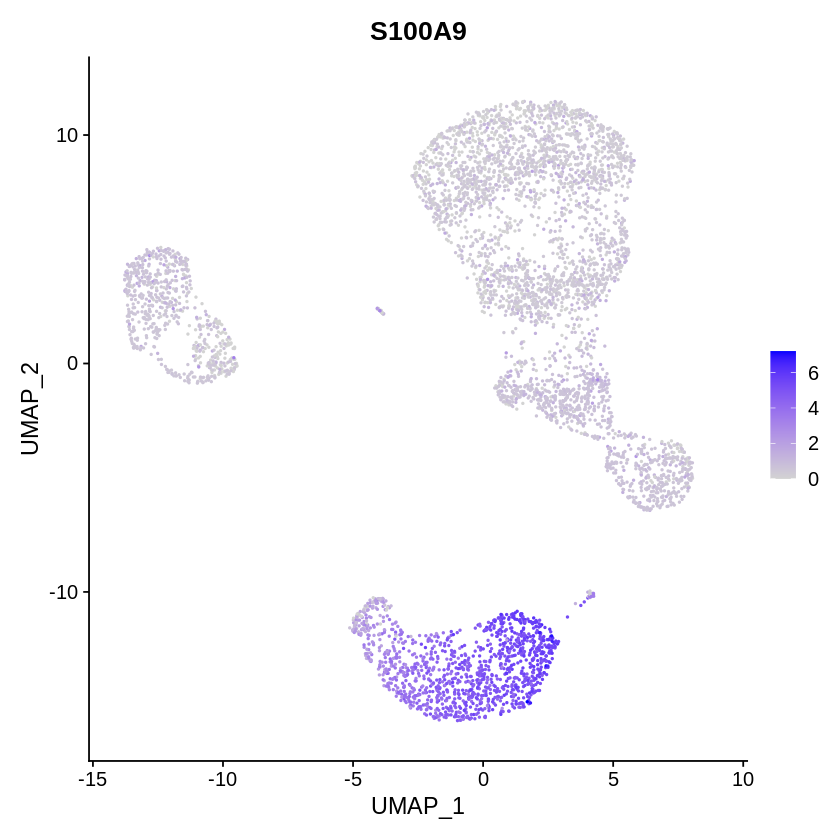

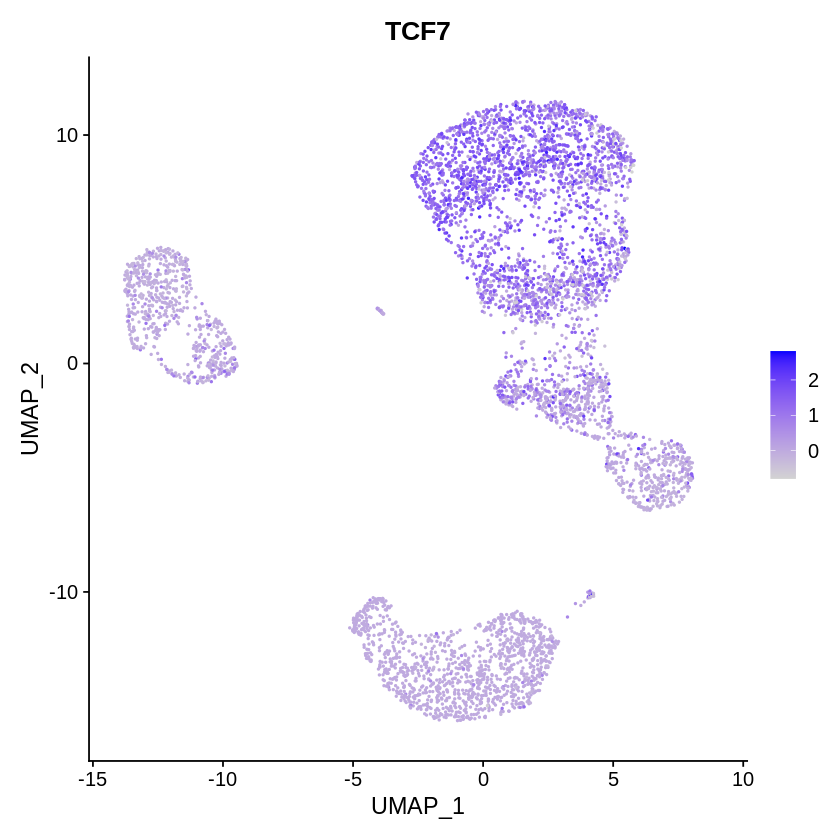

In [65]:
FeaturePlot(su3_1, features = "S100A9")
FeaturePlot(su3_1, features = "TCF7")

# Cluster Annotation

## Load the package

In [66]:
library(scHCL)

Warning message:
“replacing previous import ‘shiny::dataTableOutput’ by ‘DT::dataTableOutput’ when loading ‘scHCL’”
Warning message:
“replacing previous import ‘shiny::renderDataTable’ by ‘DT::renderDataTable’ when loading ‘scHCL’”


## Annotation

In [67]:
pbmc_for_annotation <- GetAssayData(su3_1, slot="data")
pbmc_cell_type <- scHCL(scdata = pbmc_for_annotation, numbers_plot = 3)

Warning message in log(tst.expr + 1):
“NaNs produced”


## Add to metadata

In [68]:
out <- as.data.frame(unlist(pbmc_cell_type$scHCL))
su3_1@meta.data$cell_type <- out[match(rownames(su3_1@meta.data),rownames(out)),1]

## Outputs

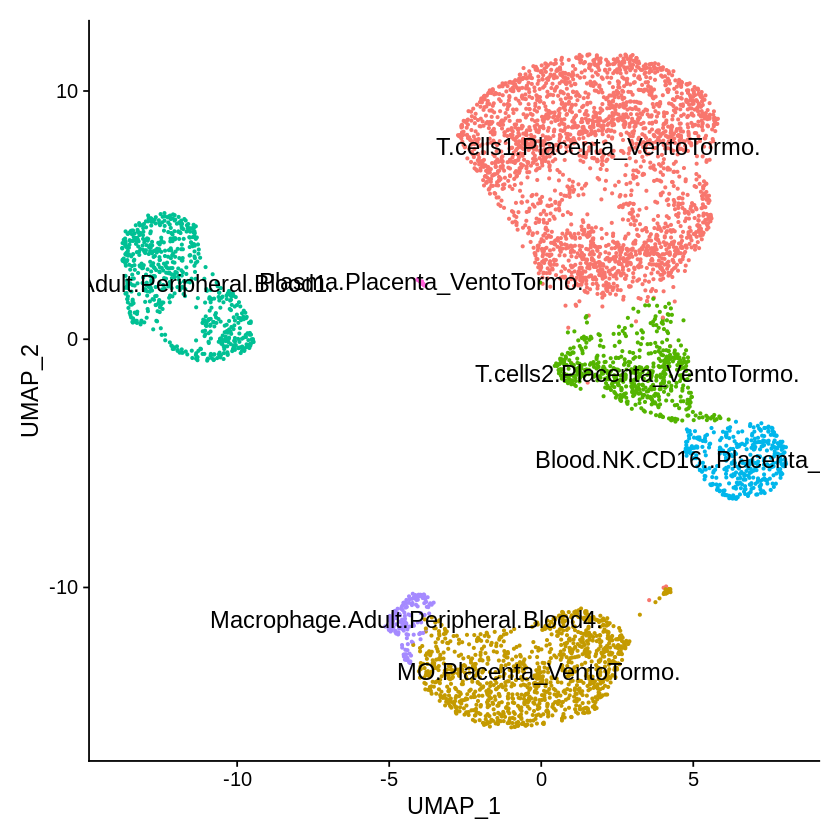

In [69]:
out_meta <- su3_1@meta.data

cluster_anno <- as.data.frame(table(su3_1@meta.data$cell_type,su3_1@meta.data$seurat_clusters))
sorted_cluster_anno <- cluster_anno[order(cluster_anno$Var2,-cluster_anno$Freq),]
finl_cluster_anno <- sorted_cluster_anno[!duplicated(sorted_cluster_anno$Var2),]
finl_cluster_anno <- finl_cluster_anno[,c(1,2)]
colnames(finl_cluster_anno) <- c("CellType","Cluster")
finl_cluster_anno$CellType <- as.character(finl_cluster_anno$CellType)
id <- finl_cluster_anno$CellType

write.csv(id,"./outputs/final_cluster_anno1.csv")

id<- read.csv(paste("./outputs/final_cluster_anno1.csv",sep=''))

id<-id$x # Cell types, need to be data.frame
names(id) <- levels(su3_1)
su3_1 <- RenameIdents(su3_1, id)
DimPlot(su3_1, reduction = "umap", label = TRUE, label.size = 5,pt.size = 0.5)+ NoLegend()

su3_1@meta.data$predicted_celltype <- su3_1@active.ident

In [ ]:
saveRDS(su3_1,"hw1.rds")